# Conect Drive

In [ ]:
from google.colab import drive
drive.mount('./content')

Mounted at ./content


# Library

In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
from torch.utils.data import ConcatDataset
import matplotlib.pyplot as plt
import torch.optim as optim
from collections import deque
import numpy as np
import pickle
import sys
import cv2
import re
import gc
import psutil
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import pandas as pd
import seaborn as sns

# Load Images

In [ ]:
unlabel_train_path = '/content/content/MyDrive/MVTec/bottle/train/good'
unlabel_test_path = '/content/content/MyDrive/MVTec/bottle/test/good'
label_path = '/content/content/MyDrive/MVTec/bottle/test'
ground_truth_path = '/content/content/MyDrive/MVTec/bottle/ground_truth'

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), fill=0),
    transforms.RandomAffine(degrees=0, shear=20, fill=0),
    #transforms.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0))
])

def add_gaussian_noise(image, mean=0, std=0.1):
    noise = torch.randn_like(image[:3]) * std + mean
    image[:3] += noise
    return torch.clamp(image, 0., 1.)

In [ ]:
def filtering(input):
    """
    Compute R_clone using Sobel edge detection after applying Gaussian blur on grayscale patches.
    Encourages the model to focus on edges and boundaries.

    Parameters:
        patches: Tensor of shape [batch, channels, height, width]
                 (image patches)

    Returns:
        Scalar tensor representing R_clone.
    """
    # Define Sobel filters
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)

    # Convert to grayscale using weighted sum of RGB channels
    gray_image = 0.2989 * input[:, 0:1, :, :] + 0.5870 * input[:, 1:2, :, :] + 0.1140 * input[:, 2:3, :, :]

    # Apply Gaussian Blur (define a simple 5x5 kernel)
    kernel = torch.tensor([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]], dtype=torch.float32).view(1, 1, 5, 5) / 256.0
    smoothed_image = F.conv2d(gray_image, kernel.to(input.device), padding=2)

    # Apply Sobel filters to the blurred image
    edges_x = F.conv2d(smoothed_image, sobel_x.to(input.device), padding=1)
    edges_y = F.conv2d(smoothed_image, sobel_y.to(input.device), padding=1)

    # Compute edge intensity
    edge_intensity = torch.sqrt(edges_x**2 + edges_y**2)

    return edge_intensity

In [ ]:
'''
class ImageLoaderDataset(Dataset):
    def __init__(self, directory_path, transform=None, ignore_folders=None, subfolder=True, include_history=True,
                 include_loss_history=True, padding=True, padding_mode='constant', patch_size=64, crop_size=128, move_size=24, gray=False):
        """
        A custom Dataset class for loading images with optional padding and additional history/loss history layers.

        Parameters:
            directory_path (str): Path to the folder containing images.
            transform (callable, optional): A function/transform to apply to the images.
            ignore_folders (list, optional): Folders to ignore while loading images.
            subfolder (bool, optional): If True, load images from subfolders.
            include_history (bool, optional): If True, adds a binary history layer to each image.
            include_loss_history (bool, optional): If True, adds a loss history layer to each image.
            padding (bool, optional): Whether to add padding to the images.
            padding_mode (str, optional): The type of padding to apply (e.g., 'constant', 'reflect', etc.).
            patch_size (int): The size of the patches to be extracted.
            crop_size (int): The size of the crop/patch extracted initially.
            move_size (int): The size of the movement for the center of the patch.
        """
        self.directory_path = directory_path
        self.transform = transform if transform else transforms.ToTensor()
        self.ignore_folders = ignore_folders if ignore_folders else []
        self.subfolder = subfolder
        self.include_history = include_history
        self.include_loss_history = include_loss_history
        self.padding = padding
        self.padding_mode = padding_mode
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.move_size = move_size
        self.gray = gray
        self.group_indices = {}
        self.image_paths = self._load_image_paths()

    def _load_image_paths(self):
        """
        Loads the paths of all images in the directory, including subfolders if specified.

        Returns:
            list: A list of paths to the image files.
        """
        image_paths = []
        if self.subfolder:
            start_idx = 0
            subfolders = sorted(os.listdir(self.directory_path))
            subfolders = [sf for sf in subfolders if sf not in self.ignore_folders]
            print('Sorted Subfloders:')
            print(subfolders)
            for subfolder in subfolders:
                subfolder_path = os.path.join(self.directory_path, subfolder)
                if os.path.isdir(subfolder_path):
                    image_names = sorted(os.listdir(subfolder_path))
                    for img_name in image_names:
                        print(f'name image in subfolder {subfolder_path}')
                        print(img_name)
                        img_path = os.path.join(subfolder_path, img_name)
                        if img_path.endswith((".png", ".jpg", ".jpeg")):
                            image_paths.append(img_path)
                    end_idx = start_idx + len(image_names) - 1
                    self.group_indices[subfolder] = (start_idx, end_idx)
                    start_idx = end_idx + 1
        else:
            image_names = sorted(os.listdir(self.directory_path))
            for img_name in image_names:
                img_path = os.path.join(self.directory_path, img_name)
                if img_path.endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(img_path)
        return image_paths

    def __len__(self):
        """Returns the number of images in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Loads an image and applies the specified transformations.

        Parameters:
            idx (int): Index of the image to load.

        Returns:
            torch.Tensor: The transformed image tensor.
        """
        img_path = self.image_paths[idx]
        if self.gray:
          img = Image.open(img_path).convert("1") # Binary-Scale for Ground-Truths
        else:
          img = Image.open(img_path).convert("RGB") # RGB for Images
        img_tensor = self.transform(img)

        # Add binary history layer (initially all zeros) if enabled
        if self.include_history:
            history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, history_layer], dim=0)

        # Add loss history layer (initially all zeros) if enabled
        if self.include_loss_history:
            loss_history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, loss_history_layer], dim=0)

        # If padding is enabled, calculate and apply padding
        #if self.padding:
            # Calculate padding based on crop_size, move_size, and patch_size
            #remainder = self.crop_size // 2
            #c = remainder - self.move_size
            #calculated_padding = self.patch_size - c

            # Ensure padding is non-negative
            #calculated_padding = max(calculated_padding, 0)

            # Apply padding
            #padding = (calculated_padding, calculated_padding, calculated_padding, calculated_padding)  # (left, right, top, bottom)
            #img_tensor = F.pad(img_tensor, padding, mode=self.padding_mode, value=0)

        return img_tensor
'''

'\nclass ImageLoaderDataset(Dataset):\n    def __init__(self, directory_path, transform=None, ignore_folders=None, subfolder=True, include_history=True,\n                 include_loss_history=True, padding=True, padding_mode=\'constant\', patch_size=64, crop_size=128, move_size=24, gray=False):\n        """\n        A custom Dataset class for loading images with optional padding and additional history/loss history layers.\n\n        Parameters:\n            directory_path (str): Path to the folder containing images.\n            transform (callable, optional): A function/transform to apply to the images.\n            ignore_folders (list, optional): Folders to ignore while loading images.\n            subfolder (bool, optional): If True, load images from subfolders.\n            include_history (bool, optional): If True, adds a binary history layer to each image.\n            include_loss_history (bool, optional): If True, adds a loss history layer to each image.\n            padding (

In [ ]:
class ImageLoaderDataset(Dataset):
    def __init__(self, directory_path, transform=None, ignore_folders=None, subfolder=True, include_history=True,
                 include_loss_history=True, include_counter=True, padding=True, padding_mode='constant', patch_size=64, crop_size=128, move_size=24, gray=False):
        """
        A custom Dataset class for loading images with optional padding and additional history/loss history layers.

        Parameters:
            directory_path (str): Path to the folder containing images.
            transform (callable, optional): A function/transform to apply to the images.
            ignore_folders (list, optional): Folders to ignore while loading images.
            subfolder (bool, optional): If True, load images from subfolders.
            include_history (bool, optional): If True, adds a binary history layer to each image.
            include_loss_history (bool, optional): If True, adds a loss history layer to each image.
            include_counter (bool, optional): If True, adds a counter layer to each image.
            padding (bool, optional): Whether to add padding to the images.
            padding_mode (str, optional): The type of padding to apply (e.g., 'constant', 'reflect', etc.).
            patch_size (int): The size of the patches to be extracted.
            crop_size (int): The size of the crop/patch extracted initially.
            move_size (int): The size of the movement for the center of the patch.
        """
        self.directory_path = directory_path
        self.transform = transform if transform else transforms.ToTensor()
        self.ignore_folders = ignore_folders if ignore_folders else []
        self.subfolder = subfolder
        self.include_history = include_history
        self.include_loss_history = include_loss_history
        self.include_counter = include_counter  # Added the counter parameter
        self.padding = padding
        self.padding_mode = padding_mode
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.move_size = move_size
        self.gray = gray
        self.group_indices = {}
        self.image_paths = self._load_image_paths()

    def _load_image_paths(self):
        """
        Loads the paths of all images in the directory, including subfolders if specified.

        Returns:
            list: A list of paths to the image files.
        """
        image_paths = []
        if self.subfolder:
            start_idx = 0
            subfolders = sorted(os.listdir(self.directory_path))
            subfolders = [sf for sf in subfolders if sf not in self.ignore_folders]
            print('Sorted Subfloders:')
            print(subfolders)
            for subfolder in subfolders:
                subfolder_path = os.path.join(self.directory_path, subfolder)
                if os.path.isdir(subfolder_path):
                    image_names = sorted(os.listdir(subfolder_path))
                    for img_name in image_names:
                        print(f'name image in subfolder {subfolder_path}')
                        print(img_name)
                        img_path = os.path.join(subfolder_path, img_name)
                        if img_path.endswith((".png", ".jpg", ".jpeg")):
                            image_paths.append(img_path)
                    end_idx = start_idx + len(image_names) - 1
                    self.group_indices[subfolder] = (start_idx, end_idx)
                    start_idx = end_idx + 1
        else:
            image_names = sorted(os.listdir(self.directory_path))
            for img_name in image_names:
                img_path = os.path.join(self.directory_path, img_name)
                if img_path.endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(img_path)
        return image_paths

    def __len__(self):
        """Returns the number of images in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Loads an image and applies the specified transformations.

        Parameters:
            idx (int): Index of the image to load.

        Returns:
            torch.Tensor: The transformed image tensor.
        """
        img_path = self.image_paths[idx]
        if self.gray:
          img = Image.open(img_path).convert("1") # Binary-Scale for Ground-Truths
        else:
          img = Image.open(img_path).convert("RGB") # RGB for Images
        img_tensor = self.transform(img)

        # Add binary history layer (initially all zeros) if enabled
        if self.include_history:
            history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, history_layer], dim=0)

        # Add loss history layer (initially all zeros) if enabled
        if self.include_loss_history:
            loss_history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, loss_history_layer], dim=0)

        # Add counter layer (initially all zeros) if enabled
        if self.include_counter:
            counter_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, counter_layer], dim=0)

        return img_tensor

In [ ]:
64 - ((128 // 2) - 24)

24

In [ ]:
unlabel_train = ImageLoaderDataset(directory_path=unlabel_train_path, transform=transform, subfolder=False)
unlabel_test = ImageLoaderDataset(directory_path=unlabel_test_path, transform=transform, subfolder=False)

In [ ]:
label_dataset = ImageLoaderDataset(directory_path=label_path, transform=transform, ignore_folders=['good'],
                                   subfolder=True)

Sorted Subfloders:
['.ipynb_checkpoints', 'broken_large', 'broken_small', 'contamination']
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
000.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
001.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
002.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
003.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
004.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
005.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
006.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
007.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
008.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
009.png
name image in subfolder /cont

In [ ]:
label_dataset.group_indices

{'.ipynb_checkpoints': (0, -1),
 'broken_large': (0, 19),
 'broken_small': (20, 41),
 'contamination': (42, 62)}

In [ ]:
ground_truth = ImageLoaderDataset(directory_path=ground_truth_path, transform=transform, subfolder=True,
                                  include_history=False, include_loss_history=False, include_counter=False, gray=True)

Sorted Subfloders:
['.ipynb_checkpoints', 'broken_large', 'broken_small', 'contamination']
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
000_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
001_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
002_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
003_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
004_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
005_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
006_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
007_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
008_mask.png


In [ ]:
ground_truth.group_indices

{'.ipynb_checkpoints': (0, -1),
 'broken_large': (0, 19),
 'broken_small': (20, 41),
 'contamination': (42, 62)}

In [ ]:
print(f'num.of images unlabel train data: {len(unlabel_train)}')
print(f'num.of images unlabel test data: {len(unlabel_test)}')
print(f'num.of images label data: {len(label_dataset)}')
print(f'num.of ground-truth: {len(ground_truth)}')

num.of images unlabel train data: 209
num.of images unlabel test data: 20
num.of images label data: 63
num.of ground-truth: 63


In [ ]:
print(f'shape of images unlabel train data: {unlabel_train[0].shape}')
print(f'shape of images unlabel test data: {unlabel_test[0].shape}')
print(f'shape of images label data: {label_dataset[0].shape}')
print(f'shape of ground-truth: {ground_truth[0].shape}')

shape of images unlabel train data: torch.Size([6, 256, 256])
shape of images unlabel test data: torch.Size([6, 256, 256])
shape of images label data: torch.Size([6, 256, 256])
shape of ground-truth: torch.Size([1, 256, 256])


In [ ]:
torch.unique(ground_truth[0])

tensor([0., 1.])

In [ ]:
print(unlabel_train[0].min())
print(unlabel_train[0].max())

tensor(0.)
tensor(1.)


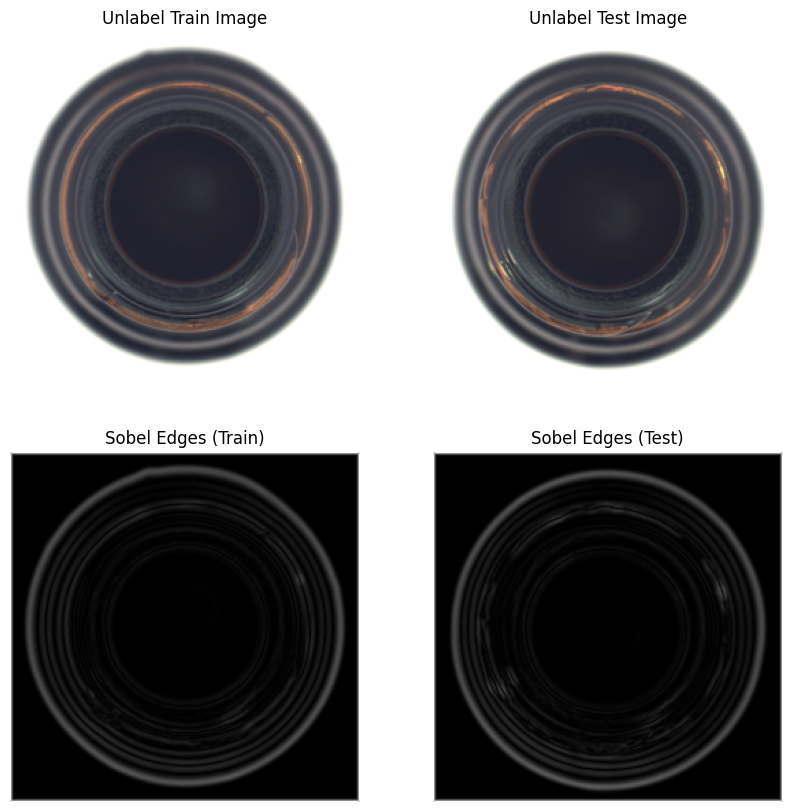

In [ ]:
# Select images and permute to change channel order (RGB)
image1 = unlabel_train[0][:3].permute(1, 2, 0).numpy()  # Train image (RGB)
image2 = unlabel_test[0][:3].permute(1, 2, 0).numpy()   # Test image (RGB)

# Apply Filtering
edge_1 = filtering(unlabel_train[0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension
edge_2 = filtering(unlabel_test[0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Display original images and edge-detected images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Display first image (original and filtered)
axes[0, 0].imshow(image1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Unlabel Train Image')

axes[1, 0].imshow(edge_1, cmap='gray')
axes[1, 0].axis('off')
axes[1, 0].set_title('Sobel Edges (Train)')

# Display second image (original and filtered)
axes[0, 1].imshow(image2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Unlabel Test Image')

axes[1, 1].imshow(edge_2, cmap='gray')
axes[1, 1].axis('off')
axes[1, 1].set_title('Sobel Edges (Test)')

# Show the final result
plt.show()

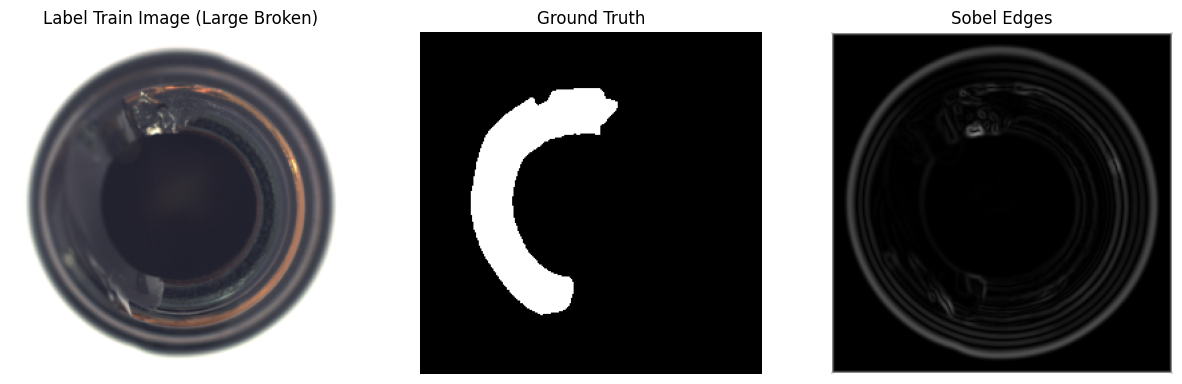

In [ ]:
# Select an image and permute channels (RGB)
image1 = label_dataset[10][:3].permute(1, 2, 0).numpy()

# Scale pixel values if in range [0, 1]
image1 = np.uint8(image1 * 255)

# Ground truth label (Grayscale)
label1 = ground_truth[10].squeeze(0).numpy()

# Apply Filtering
edge_1 = filtering(label_dataset[10][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Set up figure and subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title('Label Train Image (Large Broken)')

# Display the ground truth (Grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Ground Truth')

# Display the Sobel edge detection result
axes[2].imshow(edge_1, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Sobel Edges')

# Show the figure
plt.show()

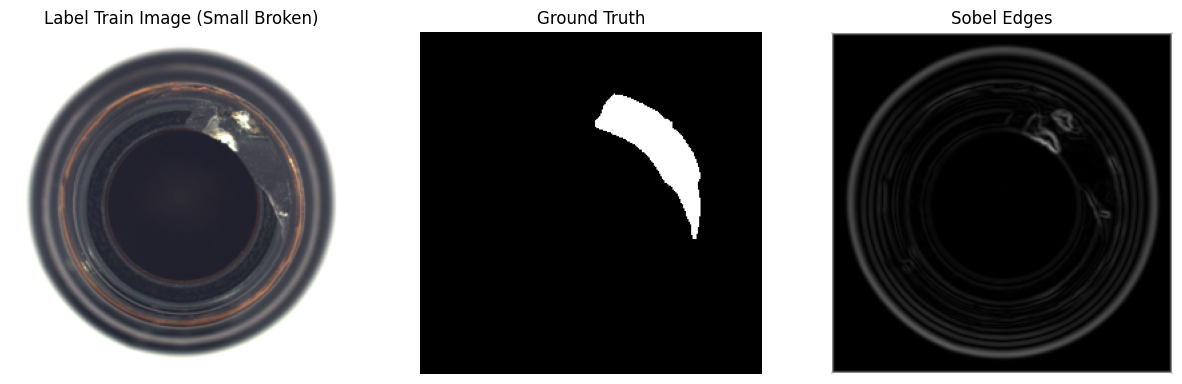

In [ ]:
# Select an image and permute channels (RGB)
image1 = label_dataset[30][:3].permute(1, 2, 0).numpy()

# Scale pixel values if in range [0, 1]
image1 = np.uint8(image1 * 255)

# Ground truth label (Grayscale)
label1 = ground_truth[30].squeeze(0).numpy()

# Apply Filtering
edge_1 = filtering(label_dataset[30][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Set up figure and subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title('Label Train Image (Small Broken)')

# Display the ground truth (Grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Ground Truth')

# Display the Sobel edge detection result
axes[2].imshow(edge_1, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Sobel Edges')

# Show the figure
plt.show()

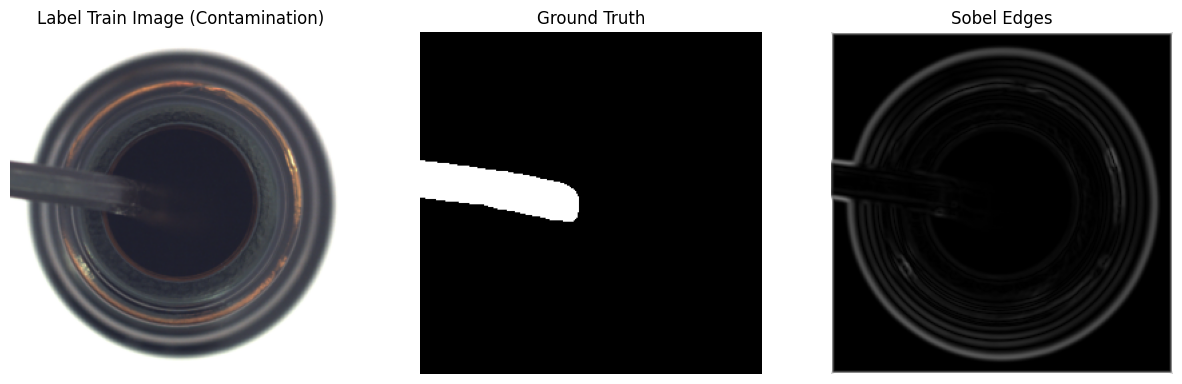

In [ ]:
# Select an image and permute channels (RGB)
image1 = label_dataset[55][:3].permute(1, 2, 0).numpy()

# Scale pixel values if in range [0, 1]
image1 = np.uint8(image1 * 255)

# Ground truth label (Grayscale)
label1 = ground_truth[55].squeeze(0).numpy()

# Apply Filtering
edge_1 = filtering(label_dataset[55][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Set up figure and subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title('Label Train Image (Contamination)')

# Display the ground truth (Grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Ground Truth')

# Display the Sobel edge detection result
axes[2].imshow(edge_1, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Sobel Edges')

# Show the figure
plt.show()

In [ ]:
random.seed(42)

label_train = []
groundtruth_train = []
label_test = []
groundtruth_test = []

for group, (start_idx, end_idx) in label_dataset.group_indices.items():
    if group != '.ipynb_checkpoints':
      random_indices = random.sample(range(start_idx, end_idx + 1), 5)
      for idx in random_indices:
        label_train.append(label_dataset[idx])
        groundtruth_train.append(ground_truth[idx])

      remaining_indices = [i for i in range(start_idx, end_idx + 1) if i not in random_indices]
      for idx in remaining_indices:
        label_test.append(label_dataset[idx])
        groundtruth_test.append(ground_truth[idx])

In [ ]:
print(len(label_train))

15


In [ ]:
default_ground_truth = torch.ones(1)

In [ ]:
train_data = list(zip(label_train, groundtruth_train)) + [(data, default_ground_truth) for data in unlabel_train]
test_data = list(zip(label_test, groundtruth_test)) + [(data, default_ground_truth) for data in unlabel_test]

In [ ]:
print(f'Number of training samples: {len(train_data)}')
print(f'Number of test samples: {len(test_data)}')

Number of training samples: 224
Number of test samples: 68


In [ ]:
random.shuffle(train_data)
random.shuffle(test_data)

print(f'Number of training samples after shuffle: {len(train_data)}')
print(f'Number of test samples after shuffle: {len(test_data)}')

Number of training samples after shuffle: 224
Number of test samples after shuffle: 68


In [ ]:
def apply_augmentation(image, label):

    image_rgb = image[:3]
    image_extra = image[3:]

    state = torch.get_rng_state()
    augmented_rgb = augmentation(image_rgb)
    torch.set_rng_state(state)
    augmented_labels = augmentation(label)

    augmented_image = torch.cat([augmented_rgb, image_extra], dim=0)

    del image_rgb, image_extra, augmented_rgb
    gc.collect()
    os.system('echo 1 > /proc/sys/vm/drop_caches')
    return augmented_image, augmented_labels

In [ ]:
final_train = []
num_augmentations = 2

# Assuming train_data is a list of tuples: (image, ground_truth)
for image, label in train_data:
    final_train.append((image, label))

    # Iterate over each (image, ground_truth) pair in train_data
    for _ in range(num_augmentations):
        # Apply augmentation to ground_truth only if it's not a fixed value like tensor([1])
        if not torch.equal(label, torch.tensor([1.0])):  # Check if labels are not tensor([1])
            augmented_image, augmented_labels = apply_augmentation(image, label)
            augmented_image = add_gaussian_noise(augmented_image)
        else:
            augmented_image = augmentation(image)
            augmented_image = add_gaussian_noise(augmented_image)
            augmented_labels = label  # If labels are fixed, keep them unchanged

        # After augmenting all data in this iteration, append the new augmented data pair
        final_train.append((augmented_image, augmented_labels))

In [ ]:
len(final_train)

672

In [ ]:
final_train[0][0].size()

torch.Size([6, 256, 256])

In [ ]:
user_vars = {key: value for key, value in globals().items() if not key.startswith('_') and key not in dir(__builtins__)}
print(list(user_vars.keys()))

['In', 'Out', 'exit', 'quit', 'drive', 'os', 'folder_path', 'torch', 'transforms', 'Image', 'nn', 'F', 'Dataset', 'DataLoader', 'random', 'ConcatDataset', 'plt', 'optim', 'deque', 'np', 'pickle', 'sys', 'cv2', 'gc', 'psutil', 'unlabel_train_path', 'unlabel_test_path', 'label_path', 'ground_truth_path', 'transform', 'augmentation', 'add_gaussian_noise', 'filtering', 'ImageLoaderDataset', 'unlabel_train', 'unlabel_test', 'label_dataset', 'ground_truth', 'label_train', 'groundtruth_train', 'label_test', 'groundtruth_test', 'group', 'start_idx', 'end_idx', 'random_indices', 'idx', 'remaining_indices', 'default_ground_truth', 'train_data', 'test_data', 'apply_augmentation', 'final_train', 'num_augmentations', 'image', 'label', 'augmented_image', 'augmented_labels']


In [ ]:
vars_to_delete = [
    'ConcatDataset', 'transform', 'augmentation', 'add_gaussian_noise',
    'ImageLoaderDataset', 'apply_augmentation', 'filtering'
    "label1", "unlabel_train_path", "unlabel_test_path", "label_path",
    "ground_truth_path", "transform", "augmentation", "add_gaussian_noise",
    "unlabel_train", "unlabel_test", "image1", "image2", "label_dataset",
    "user_vars", "augmented_image", "augmented_labels", "image", "labels",
    "num_augmentations", "augmented_imgs_list", "augmented_labels_list",
    "train_data", "default_ground_truth", "remaining_indices", "label_train",
    "groundtruth_train", "label_test", "groundtruth_test", "group",
    "start_idx", "end_idxrandom_indices", "idx", "ground_truth",
]

for var in vars_to_delete:
    if var in globals():
        del globals()[var]
        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')

del vars_to_delete
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
print('Ok.')

Ok.


In [ ]:
train_data = final_train
del final_train
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')

512

In [ ]:
print(f"Memory usage: {psutil.virtual_memory().percent}%")

Memory usage: 17.2%


In [ ]:
image1 = train_data[0][0]
image2 = train_data[10][0]
image3 = train_data[100][0]
image4 = train_data[400][0]

channels1_4_5_6 = image1[3:, :, :]
channels2_4_5_6 = image2[3:, :, :]
channels3_4_5_6 = image3[3:, :, :]
channels4_4_5_6 = image4[3:, :, :]

all_zero1 = torch.all(channels1_4_5_6 == 0)
all_zero2 = torch.all(channels2_4_5_6 == 0)
all_zero3 = torch.all(channels3_4_5_6 == 0)
all_zero4 = torch.all(channels4_4_5_6 == 0)

print("Are all values in channels 4, 5, and 6 zero?", all_zero1.item())
print("Are all values in channels 4, 5, and 6 zero?", all_zero2.item())
print("Are all values in channels 4, 5, and 6 zero?", all_zero3.item())
print("Are all values in channels 4, 5, and 6 zero?", all_zero4.item())

In [ ]:
len(train_data)

In [ ]:
target_shape = torch.Size([1])
index_found = []

for idx, (image, label) in enumerate(train_data):
    if label.size() != target_shape:
        index_found.append(idx)
    if len(index_found) == 2:
      break

In [ ]:
index_found

In [ ]:
# Select two images and their corresponding labels
image1, label1 = train_data[index_found[0]]
image2, label2 = train_data[index_found[1]]
image2 = image2.float()
# Extract only the first three channels (RGB) for display
image1_rgb = image1[:3].permute(1, 2, 0)  # Rearrange dimensions for visualization
image2_rgb = image2[:3].permute(1, 2, 0)

# Convert labels to numpy for display with cmap='gray'
label1_np = label1.squeeze(0).numpy()
label2_np = label2.squeeze(0).numpy()

# Create a figure to display images and their corresponding labels
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Display the first image
axes[0, 0].imshow(image1_rgb)
axes[0, 0].axis("off")
axes[0, 0].set_title("Train Image 1")

# Display the ground truth of the first image
axes[1, 0].imshow(label1_np, cmap="gray")
axes[1, 0].axis("off")
axes[1, 0].set_title("Ground Truth 1")

# Display the second image
axes[0, 1].imshow(image2_rgb)
axes[0, 1].axis("off")
axes[0, 1].set_title("Train Image 2")

# Display the ground truth of the second image
axes[1, 1].imshow(label2_np, cmap="gray")
axes[1, 1].axis("off")
axes[1, 1].set_title("Ground Truth 2")

# Show the output
plt.show()

In [ ]:
#random.shuffle(train_data)
#random.shuffle(test_data)

In [ ]:
target_shape = torch.Size([1])
index_found = []

for idx, (image, label) in enumerate(train_data):
    if label.size() != target_shape:
        index_found.append(idx)
    if len(index_found) == 5:
      break

In [ ]:
index_found

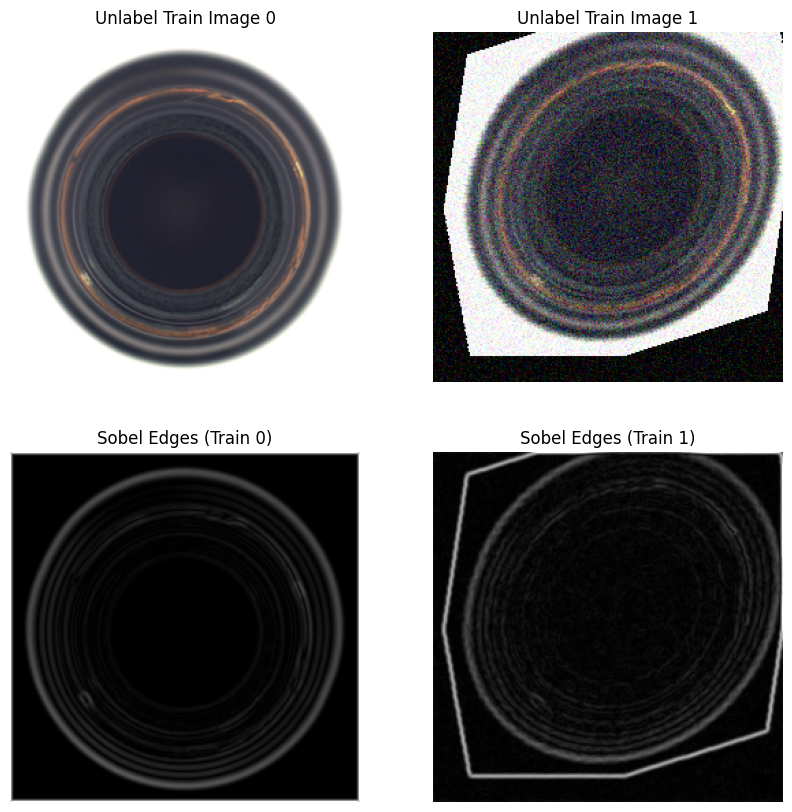

In [ ]:
# First pair of images (index 0 and 1)
image1 = train_data[0][0][:3].permute(1, 2, 0).numpy()  # Train image (RGB)
image2 = train_data[1][0][:3].permute(1, 2, 0).numpy()  # Train image (RGB)

# Scale pixel values (if in the range [0, 1])
image1 = np.uint8(image1 * 255)
image2 = np.uint8(image2 * 255)

# Apply Filtering
edge_1 = filtering(train_data[0][0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension
edge_2 = filtering(train_data[1][0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Display original images and edge-detected images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Display first image (original and filtered)
axes[0, 0].imshow(image1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Unlabel Train Image 0')

axes[1, 0].imshow(edge_1, cmap='gray')
axes[1, 0].axis('off')
axes[1, 0].set_title('Sobel Edges (Train 0)')

# Display second image (original and filtered)
axes[0, 1].imshow(image2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Unlabel Train Image 1')

axes[1, 1].imshow(edge_2, cmap='gray')
axes[1, 1].axis('off')
axes[1, 1].set_title('Sobel Edges (Train 1)')

# Show the final result
plt.show()

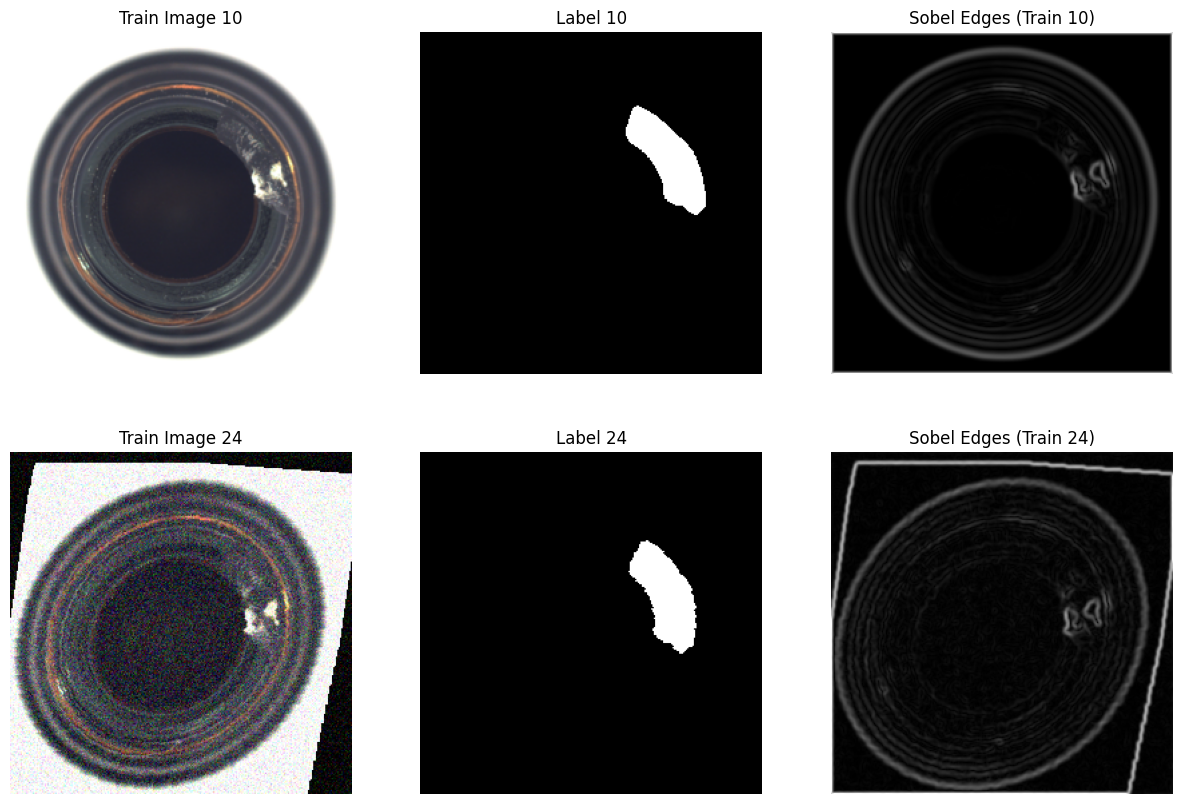

In [ ]:
# Second pair of images (index 10 and 24)
image3 = train_data[index_found[0]][0][:3].permute(1, 2, 0).numpy()  # Train image (RGB)
image4 = train_data[index_found[1]][0][:3].permute(1, 2, 0).numpy()  # Train image (RGB)

# Scale pixel values (if in the range [0, 1])
image3 = np.uint8(image3 * 255)
image4 = np.uint8(image4 * 255)

# Apply Filtering
edge_1 = filtering(train_data[index_found[0]][0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension
edge_2 = filtering(train_data[index_found[1]][0][:3].unsqueeze(0)).squeeze(0).squeeze(0)  # Adding batch dimension

# Display images and edge-detected images with their corresponding labels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Display first image (original, label, and filtered)
axes[0, 0].imshow(image3)
axes[0, 0].axis('off')
axes[0, 0].set_title('Train Image 10')

axes[0, 1].imshow(train_data[index_found[0]][1].squeeze(0).numpy(), cmap='gray')
axes[0, 1].axis('off')
axes[0, 1].set_title('Label 10')

axes[0, 2].imshow(edge_1, cmap='gray')
axes[0, 2].axis('off')
axes[0, 2].set_title('Sobel Edges (Train 10)')

# Display second image (original, label, and filtered)
axes[1, 0].imshow(image4)
axes[1, 0].axis('off')
axes[1, 0].set_title('Train Image 24')

axes[1, 1].imshow(train_data[index_found[1]][1].squeeze(0).numpy(), cmap='gray')
axes[1, 1].axis('off')
axes[1, 1].set_title('Label 24')

axes[1, 2].imshow(edge_2, cmap='gray')
axes[1, 2].axis('off')
axes[1, 2].set_title('Sobel Edges (Train 24)')

# Show the final result
plt.show()

In [ ]:
print(f"Memory usage: {psutil.virtual_memory().percent}%")

Memory usage: 22.5%


In [ ]:
del image1, image2, image3, image4
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del edge_1, edge_2
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del label1, label2, label1_np, label2_np
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del image1_rgb, image2_rgb
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del target_shape, index_found
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del channels1_4_5_6, channels2_4_5_6, channels3_4_5_6, channels4_4_5_6
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')
del all_zero1, all_zero2, all_zero3, all_zero4
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')

512

In [ ]:
user_vars = {key: value for key, value in globals().items() if not key.startswith('_') and key not in dir(__builtins__)}
print(list(user_vars.keys()))

['In', 'Out', 'exit', 'quit', 'drive', 'os', 'torch', 'transforms', 'Image', 'nn', 'F', 'Dataset', 'DataLoader', 'random', 'plt', 'optim', 'deque', 'np', 'pickle', 'sys', 'cv2', 'gc', 'psutil', 'filtering', 'fig', 'axes', 'end_idx', 'random_indices', 'test_data', 'label', 'var', 'train_data', 'idx', 'image']


In [ ]:
del idx, image, user_vars, label, var, random_indices, end_idx
gc.collect()
os.system('echo 1 > /proc/sys/vm/drop_caches')

512

In [ ]:
print(f"Memory usage: {psutil.virtual_memory().percent}%")

Memory usage: 22.5%


In [ ]:
'''
class ZippedDataset(Dataset):
    """
    A custom Dataset class for combining two datasets into one, returning a pair of data from each dataset.

    This class allows you to load data from two datasets simultaneously and retrieve corresponding pairs
    of data (e.g., images and their corresponding ground truth) by zipping the two datasets together.

    Parameters:
        dataset1 (Dataset): The first dataset (e.g., labeled images).
        dataset2 (Dataset): The second dataset (e.g., ground truth or another set of images).
    """
    def __init__(self, dataset1, dataset2):
        """
        Initializes the ZippedDataset with two datasets.

        Parameters:
            dataset1 (Dataset): The first dataset to combine.
            dataset2 (Dataset): The second dataset to combine.
        """
        self.dataset1 = dataset1  # Assign the first dataset
        self.dataset2 = dataset2  # Assign the second dataset

    def __len__(self):
        """
        Returns the length of the combined dataset. The length is determined by the smaller dataset
        to ensure we don't run out of data from either dataset.

        Returns:
            int: The number of items in the combined dataset, which is the minimum of the lengths of the two datasets.
        """
        return min(len(self.dataset1), len(self.dataset2))  # Return the minimum length between the two datasets

    def __getitem__(self, idx):
        """
        Retrieves a pair of data (e.g., an image from dataset1 and its corresponding item from dataset2)
        for the given index.

        Parameters:
            idx (int): The index to retrieve the data from both datasets.

        Returns:
            tuple: A tuple containing the data from both datasets. Typically, this is (data1, data2).
                Example: (image_from_dataset1, ground_truth_image_from_dataset2).
        """
        data1_image = self.dataset1[idx]  # Get the image (or data) from dataset1
        data2_image = self.dataset2[idx]  # Get the corresponding image (or data) from dataset2

        return data1_image, data2_image  # Return the pair of data


def combine_datasets(dataset1, dataset2):
    """
    Combine two datasets into a single dataset.

    Parameters:
        dataset1 (Dataset): The first dataset.
        dataset2 (Dataset): The second dataset.

    Returns:
        Dataset: A new dataset that combines the two input datasets.
    """
    # Combine the datasets using ConcatDataset
    combined_dataset = ConcatDataset([dataset1, dataset2])
    return combined_dataset

class UnlabeledDatasetWrapper(Dataset):
    """
    A wrapper for unlabeled datasets to add a None label for each data item.

    This class allows you to work with unlabeled datasets by adding a placeholder
    label (`None`) for compatibility with labeled datasets.
    """
    def __init__(self, dataset):
        """
        Initialize the wrapper with an unlabeled dataset.

        Parameters:
            dataset (Dataset): The original unlabeled dataset.
        """
        self.dataset = dataset

    def __len__(self):
        """
        Returns the number of items in the dataset.

        Returns:
            int: The length of the dataset.
        """
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Retrieve an item from the dataset and add a None label.

        Parameters:
            idx (int): The index of the item to retrieve.

        Returns:
            tuple: A tuple containing the data and a None label (data, None).
        """
        data = self.dataset[idx]
        return data, 1
'''

'\nclass ZippedDataset(Dataset):\n    """\n    A custom Dataset class for combining two datasets into one, returning a pair of data from each dataset.\n\n    This class allows you to load data from two datasets simultaneously and retrieve corresponding pairs\n    of data (e.g., images and their corresponding ground truth) by zipping the two datasets together.\n\n    Parameters:\n        dataset1 (Dataset): The first dataset (e.g., labeled images).\n        dataset2 (Dataset): The second dataset (e.g., ground truth or another set of images).\n    """\n    def __init__(self, dataset1, dataset2):\n        """\n        Initializes the ZippedDataset with two datasets.\n\n        Parameters:\n            dataset1 (Dataset): The first dataset to combine.\n            dataset2 (Dataset): The second dataset to combine.\n        """\n        self.dataset1 = dataset1  # Assign the first dataset\n        self.dataset2 = dataset2  # Assign the second dataset\n\n    def __len__(self):\n        """\n

In [ ]:
'''
full_label_dataset = ZippedDataset(label_dataset, ground_truth)
unlabel_dataset = combine_datasets(unlabel_train, unlabel_test)
'''

'\nfull_label_dataset = ZippedDataset(label_dataset, ground_truth)\nunlabel_dataset = combine_datasets(unlabel_train, unlabel_test)\n'

In [ ]:
'''
print(f'num.of images full label data: {len(full_label_dataset)}')
print(f'num.of images pair full label data: {len(full_label_dataset[0])}')
print(f'shape of images label data: {full_label_dataset[0][0].shape}')
print(f'shape of images ground-truth: {full_label_dataset[0][1].shape}')
print(f'num.of images unlabel data: {len(unlabel_dataset)}')
print(f'shape of images unlabel train data: {unlabel_dataset[0].shape}')
'''

"\nprint(f'num.of images full label data: {len(full_label_dataset)}')\nprint(f'num.of images pair full label data: {len(full_label_dataset[0])}')\nprint(f'shape of images label data: {full_label_dataset[0][0].shape}')\nprint(f'shape of images ground-truth: {full_label_dataset[0][1].shape}')\nprint(f'num.of images unlabel data: {len(unlabel_dataset)}')\nprint(f'shape of images unlabel train data: {unlabel_dataset[0].shape}')\n"

In [ ]:
'''
wrapped_unlabeled_dataset = UnlabeledDatasetWrapper(unlabel_dataset)
'''

'\nwrapped_unlabeled_dataset = UnlabeledDatasetWrapper(unlabel_dataset)\n'

In [ ]:
'''
print(f'num.of images unlabel data: {len(wrapped_unlabeled_dataset)}')
print(f'num.of iamges pair unlabel: {len(wrapped_unlabeled_dataset[0])}')
print(f'shape of images unlabel: {wrapped_unlabeled_dataset[0][0].shape}')
print(f'{wrapped_unlabeled_dataset[0][1]}')
'''

"\nprint(f'num.of images unlabel data: {len(wrapped_unlabeled_dataset)}')\nprint(f'num.of iamges pair unlabel: {len(wrapped_unlabeled_dataset[0])}')\nprint(f'shape of images unlabel: {wrapped_unlabeled_dataset[0][0].shape}')\nprint(f'{wrapped_unlabeled_dataset[0][1]}')\n"

In [ ]:
'''
final_dataset = combine_datasets(full_label_dataset, wrapped_unlabeled_dataset)
'''

'\nfinal_dataset = combine_datasets(full_label_dataset, wrapped_unlabeled_dataset)\n'

In [ ]:
'''
print(f'{len(final_dataset)}')
print(f'{len(final_dataset[0])}')
print(f'{final_dataset[0][0].shape}')
print(f'{final_dataset[0][1].shape}')
print(f'{final_dataset[200][0].shape}')
print(f'{final_dataset[200][1]}')
'''

"\nprint(f'{len(final_dataset)}')\nprint(f'{len(final_dataset[0])}')\nprint(f'{final_dataset[0][0].shape}')\nprint(f'{final_dataset[0][1].shape}')\nprint(f'{final_dataset[200][0].shape}')\nprint(f'{final_dataset[200][1]}')\n"

In [ ]:
'''
dataloader = DataLoader(final_dataset, batch_size=1, shuffle=True)
'''

'\ndataloader = DataLoader(final_dataset, batch_size=1, shuffle=True)\n'

# Neural Batch Sampler Class

In [ ]:
class NeuralBatchSampler(nn.Module):
    def __init__(self, input_size=900, crop_size=128, patch_size=64, move_size=24, action_space=9):
        """
        Initialize the NeuralBatchSampler class with necessary parameters.

        Parameters:
            input_size (int): The size of the input image (height/width).
            crop_size (int): The size of the crop/patch extracted from the image.
            patch_size (int): The size of the patches used in the network.
            move_size (int): The size by which the center of the patch is moved.
            action_space (int): The number of possible actions (directions).
        """
        super(NeuralBatchSampler, self).__init__()
        self.input_size = input_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.move_size = move_size
        self.action_space = action_space

        # Define convolutional layers for feature extraction
        self.conv1 = nn.Conv2d(6, 16, kernel_size=3, stride=2, padding=1)  # First convolution layer (5 input channels)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)

        # Fully connected layers for final classification/output
        self.fc1 = nn.Linear(64 * 4 * 4, 256)  # Linear layer after convolutional layers (flattened)
        self.fc2 = nn.Linear(256, action_space)  # Output layer with number of actions

        # Batch normalization layers to improve training stability
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(32)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(64)

    def forward(self, patches):
        """
        Forward pass for the model, performing feature extraction and classification.

        Parameters:
            patches (Tensor): The image patches to be passed through the network.
            num_episode (int): The current episode number, used to change the input channels.

        Returns:
            Tensor: The predicted action probabilities from the network (softmax output).
        """
        # Forward pass through convolutional layers with ReLU activations and batch normalization
        #patches = patches.permute(0, 3, 1, 2) # Assume input might be (batch_size, height, width, channels)
        x = self.conv1(patches)
        x = F.relu(x)
        x = self.bn1(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = F.relu(x)
        x = self.bn4(x)

        x = self.conv5(x)
        x = F.relu(x)
        x = self.bn5(x)

        # Flatten the feature map and pass through fully connected layers
        x = torch.flatten(x, start_dim=1)
        #print("Flattened shape:", x.shape)
        x = F.relu(self.fc1(x))  # First fully connected layer with ReLU activation
        x = F.softmax(self.fc2(x), dim=1)  # Output layer with softmax activation to get action probabilities

        return x
    '''
    def select_crops(self, images, centers=None):
        """
        Select crops from the images based on the specified centers. If no centers are provided,
        they will be randomly generated within the valid range.

        Parameters:
            images (Tensor): The batch of input images from which patches will be extracted.
            centers (Tensor, optional): The center coordinates of the patches. If None, will be randomly generated.

        Returns:
            Tuple: A tuple containing:
                - patches (Tensor): The extracted image patches.
                - centers (Tensor): The center coordinates used for extracting the patches.
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
          batch_size, channels, _, _ = images.shape
          height, width = self.input_size, self.input_size
          # If no centers are provided, randomly generate them within valid bounds
          #if centers is None:
              #x_centers = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (batch_size,))
              #y_centers = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (batch_size,))
              #centers = torch.stack([x_centers, y_centers], dim=1)

          # Calculate the starting and ending coordinates for each patch
          x_starts = centers[:, 0] - self.crop_size // 2
          y_starts = centers[:, 1] - self.crop_size // 2
          x_ends = x_starts + self.crop_size
          y_ends = y_starts + self.crop_size


        crops = torch.zeros((batch_size, channels, self.crop_size, self.crop_size), device=images.device)
        for i in range(batch_size):
            # Ensure coordinates are within bounds
            x_start = max(0, x_starts[i])
            y_start = max(0, y_starts[i])
            x_end = min(width, x_ends[i])
            y_end = min(height, y_ends[i])

            crop = images[i, :, y_start:y_end, x_start:x_end]
            crops[i, :, :crop.shape[1], :crop.shape[2]] = crop
            del crop

        return crops, centers
    '''
    def select_crops(self, image, center=None):
      """
      Select a crop from the image based on the specified center. If no center is provided,
      it will be randomly generated within the valid range.

      Parameters:
          image (Tensor): The input image from which the patch will be extracted.
          center (Tensor, optional): The center coordinates of the patch. If None, will be randomly generated.

      Returns:
          Tuple: A tuple containing:
              - patch (Tensor): The extracted image patch.
              - center (Tensor): The center coordinates used for extracting the patch.
      """
      # Use no_grad since we don't need gradient computation here
      with torch.no_grad():
        batch_size, channels, _, _ = image.shape
        height, width = self.input_size, self.input_size
        '''
        if center is None:
            # If no center is provided, randomly generate one within valid bounds
            center_x = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (1,))
            center_y = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (1,))
            center = torch.stack([center_x, center_y], dim=0)
        '''
        center[0] = int(center[0].item())
        center[1] = int(center[1].item())
        if (center[0] - (self.crop_size // 2)) < 0:
          center[0] = center[0] + (self.crop_size // 2 - center[0])
        elif (center[0] + self.crop_size // 2) > height:
          c = height - center[0]
          cc = (self.crop_size // 2) - c
          center[0] = center[0] - cc

        if (center[1] - (self.crop_size // 2)) < 0:
          center[1] = center[1] + (self.crop_size // 2 - center[1])
        elif (center[1] + self.crop_size // 2) > width:
          c = width - center[1]
          cc = (self.crop_size // 2) - c
          center[1] = center[1] - cc

        # Calculate the starting and ending coordinates for the crop
        x_start = int(center[0] - self.crop_size // 2)
        y_start = int(center[1] - self.crop_size // 2)
        x_end = x_start + self.crop_size
        y_end = y_start + self.crop_size

        # Extract the patch from the image
        patch = image[:, :, y_start:y_end, x_start:x_end]

        return patch, center

    '''
    def move_select_patches(self, centers, actions, images):
        """
        Move the selected patches based on the given actions. The patches are moved by a specified move size
        in the image and the history layer is updated accordingly.

        Parameters:
            centers (Tensor): The current centers of the patches.
            actions (Tensor): The actions specifying the movement direction for each patch.
            images (Tensor): The input batch of images.

        Returns:
            Tuple: A tuple containing:
              - move_mask (Tensor): A binary mask indicating which patches were moved (shape: [batch_size]).
              - rows (Tensor): Row indices used for extracting patches (shape: [num_moved_patches, patch_size]).
              - cols (Tensor): Column indices used for extracting patches (shape: [num_moved_patches, patch_size]).
              - patches (Tensor): The extracted image patches after movement (shape: [num_moved_patches, channels, patch_size, patch_size]).
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
          batch_size, channels, ـ, ـ = images.shape
          height, width = self.input_size, self.input_size
          """
          Define the movement directions (dx, dy) for the actions:
            Action 1: Move up-left    -> dx = , dy =
            Action 2: Move down-left  -> dx = -move_size, dy =
            Action 3: Move up-right   -> dx = +move_size, dy = 0
            Action 4: Move down-right -> dx = +move_size, dy = 0
            Action 5: Stay (no movement) -> dx = 0, dy = 0
            Action 6: Move left       -> dx = -move_size, dy = +move_size
            Action 7: Move right      -> dx = +move_size, dy = +move_size
            Action 8: Move down-left  -> dx = -move_size, dy = -move_size
            Action 9: Move down-right -> dx = +move_size, dy = -move_size
          """
          dx = torch.tensor([float('nan'), -self.move_size, self.move_size, 0, 0, -self.move_size, -self.move_size, self.move_size, self.move_size])
          dy = torch.tensor([float('nan'), 0, 0, -self.move_size, self.move_size, -self.move_size, self.move_size, -self.move_size, self.move_size])

          if not isinstance(actions, torch.Tensor):
              actions = torch.tensor(actions)

          actions = actions.long()
          # Create a mask for which patches will be moved (i.e., actions != 0)
          move_mask = actions != 0
          new_x = centers[:, 0].clone()
          new_x = new_x.float()
          new_y = centers[:, 1].clone()
          new_y = new_y.float()

          # Update the centers based on the actions
          new_x[move_mask] += dx[actions[move_mask]]
          new_y[move_mask] += dy[actions[move_mask]]

          # Clamp the new centers within the valid range
          new_x[~move_mask] = float('nan')
          new_y[~move_mask] = float('nan')
          new_x = new_x.clamp(0, self.input_size - 1)
          new_y = new_y.clamp(0, self.input_size - 1)

          # Stack the new x and y coordinates to form the new centers
          new_centers = torch.stack([new_x, new_y], dim=1)

          patches = []
          half_patch = self.patch_size // 2
          for i in range(batch_size):
            if not move_mask[i]:
              continue

            x_start = int(new_x[i].item()) - half_patch
            y_start = int(new_y[i].item()) - half_patch
            x_end = x_start + self.patch_size
            y_end = y_start + self.patch_size

            # Extract patch
            patch = images[i, :3, y_start:y_end, x_start:x_end]
            patches.append(patch)

            # Update the history layer
            images[i, 3, y_start:y_end, x_start:x_end] = 1

        # Convert patches to a tensor
        patches = torch.stack(patches) if patches else torch.empty(0, 3, self.patch_size, self.patch_size, device=images.device)
        return move_mask, new_centers, patches
    '''
    def move_select_patches(self, center, action, image):
      """
      Move the selected patch based on the given action. The patch is moved by a specified move size
      in the image and the history layer is updated accordingly.

      Parameters:
          center (Tensor): The current center of the patch (shape: [2]).
          action (int): A single action specifying the movement direction for the patch.
          image (Tensor): The input image (shape: [channels, height, width]).

      Returns:
          Tuple: A tuple containing:
            - move_mask (Tensor): A binary mask indicating if the patch was moved (scalar).
            - new_center (Tensor): The updated center of the patch (shape: [2]).
            - patch (Tensor): The extracted image patch after movement (shape: [channels, patch_size, patch_size]).
      """
      with torch.no_grad():
        batch_size, channels, _, _ = image.shape
        height, width = self.input_size, self.input_size
        # Define the movement directions (dx, dy) for the actions
        dx = torch.tensor([float('nan'), -self.move_size, self.move_size, 0, 0, -self.move_size, -self.move_size, self.move_size, self.move_size])
        dy = torch.tensor([float('nan'), 0, 0, -self.move_size, self.move_size, -self.move_size, self.move_size, -self.move_size, self.move_size])

        # Clone the current center and convert to float
        new_x = center[0].clone().float()
        new_y = center[1].clone().float()

        new_x += dx[action]
        new_y += dy[action]
        # Clamp the new center within the valid range of the image
        new_x = torch.clamp(new_x, min=self.crop_size // 2, max=width - self.crop_size // 2)
        new_y = torch.clamp(new_y, min=self.crop_size // 2, max=height - self.crop_size // 2)


        # Stack the new x and y coordinates to form the new center
        new_center = torch.tensor([new_x, new_y])

        # Extract the patch based on the new center
        half_patch = self.patch_size // 2
        x_start = int(new_x) - half_patch
        y_start = int(new_y) - half_patch
        x_end = x_start + self.patch_size
        y_end = y_start + self.patch_size

        patch = image[:, :3, y_start:y_end, x_start:x_end]

        # Update the history layer
        image[:, 3, y_start:y_end, x_start:x_end] = 1  # Assuming history layer is the 4th channel

        mask_inside_patch = torch.zeros_like(image[:, 5, :, :])  # Create a mask of all ones
        mask_inside_patch[:, y_start:y_end, x_start:x_end] = 1  # Set patch area to 1

        # Add 1 to the counter layer for the pixels inside the patch
        image[:, 5, :, :] += mask_inside_patch

        del mask_inside_patch
        gc.collect()
        torch.cuda.empty_cache()

        patch_channel_6 = image[:, 5, y_start:y_end, x_start:x_end]

        return patch, patch_channel_6, new_center

    def initial_patches(self, images):
        """
        Randomly initialize patch centers and extract patches from the images.

        Parameters:
            images (Tensor): The input batch of images (shape: [batch_size, channels, height, width]).

        Returns:
            Tuple:
                - patches (Tensor): The extracted patches of shape [batch_size, channels, patch_size, patch_size].
                - centers (Tensor): The randomly selected centers of the patches (shape: [batch_size, 2]).
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
          batch_size, channels, height, width = images.shape

          # Generate random centers within valid bounds
          x_centers = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (batch_size,), device=images.device)
          y_centers = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (batch_size,), device=images.device)
          centers = torch.stack([x_centers, y_centers], dim=1)


          x_starts = centers[:, 0] - self.patch_size // 2
          y_starts = centers[:, 1] - self.patch_size // 2
          x_ends = x_starts + self.patch_size
          y_ends = y_starts + self.patch_size
          # Initialize tensor for patches
          patches = torch.zeros((batch_size, 3, self.patch_size, self.patch_size), device=images.device)
          patches_channel_6 = torch.zeros((batch_size, 1, self.patch_size, self.patch_size), device=images.device)
          # Extract patches based on the random centers
          for i in range(batch_size):
              # Extract the patch and assign it to the corresponding position
              patch = images[i, :3, y_starts[i]:y_ends[i], x_starts[i]:x_ends[i]]
              patches[i] = patch
              del patch
              patche_channel_6 = images[i, 5, y_starts[i]:y_ends[i], x_starts[i]:x_ends[i]]
              patches_channel_6[i] = patche_channel_6
              del patche_channel_6
              gc.collect()
              torch.cuda.empty_cache()

          return patches, patches_channel_6, centers

# AutoEncoder Class

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, K=200):
        """
        Autoencoder with 8 convolutional and 8 deconvolutional layers,
        including a shortcut connection for speeding up training.

        Parameters:
            K (int): Number of bottleneck channels.
        """
        super(Autoencoder, self).__init__()

        # Encoder
        self.conv1 = nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64, affine=False)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64, affine=False)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128, affine=False)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128, affine=False)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn5 = nn.BatchNorm2d(256, affine=False)
        self.conv6 = nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128, affine=False)
        self.conv7 = nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(64, affine=False)
        self.conv8 = nn.Conv2d(64, K, kernel_size=8, stride=1, padding=0)

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(K, 64, kernel_size=8, stride=1, padding=0)
        self.bn8 = nn.BatchNorm2d(64, affine=False)
        self.deconv2 = nn.ConvTranspose2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn9 = nn.BatchNorm2d(128, affine=False)
        self.deconv3 = nn.ConvTranspose2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn10 = nn.BatchNorm2d(256, affine=False)
        self.deconv4 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.bn11 = nn.BatchNorm2d(256, affine=False)
        self.deconv5 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.bn12 = nn.BatchNorm2d(128, affine=False)
        self.deconv6 = nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1)
        self.bn13 = nn.BatchNorm2d(128, affine=False)
        self.deconv7 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.bn14 = nn.BatchNorm2d(64, affine=False)
        self.deconv8 = nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        """
        Forward pass for the autoencoder.

        Parameters:
            x (Tensor): Input image tensor.

        Returns:
            Tensor: Reconstructed image tensor.
        """

        # Ensure input dimensions are in (batch_size, channels, height, width)
        if x.shape[1] != 3:  # Assume input might be (batch_size, height, width, channels)
            x = x.permute(0, 3, 1, 2)

        # Encoder
        x1 = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x2 = F.leaky_relu(self.bn2(self.conv2(x1)), negative_slope=0.2)
        x3 = F.leaky_relu(self.bn3(self.conv3(x2)), negative_slope=0.2)
        x4 = F.leaky_relu(self.bn4(self.conv4(x3)), negative_slope=0.2)
        x5 = F.leaky_relu(self.bn5(self.conv5(x4)), negative_slope=0.2)
        x6 = F.leaky_relu(self.bn6(self.conv6(x5)), negative_slope=0.2)
        x7 = F.leaky_relu(self.bn7(self.conv7(x6)), negative_slope=0.2)
        bottleneck = self.conv8(x7)

        # Decoder
        d1 = F.leaky_relu(self.bn8(self.deconv1(bottleneck)), 0.2)
        d2 = F.leaky_relu(self.bn9(self.deconv2(d1)), 0.2)
        d3 = F.leaky_relu(self.bn10(self.deconv3(d2)), 0.2)
        d3 = torch.cat((d3, x5), dim=1)  # Skip connection
        d4 = F.leaky_relu(self.bn11(self.deconv4(d3)), 0.2)
        d5 = F.leaky_relu(self.bn12(self.deconv5(d4)), 0.2)
        d6 = F.leaky_relu(self.bn13(self.deconv6(d5)), 0.2)
        d7 = F.leaky_relu(self.bn14(self.deconv7(d6)), 0.2)
        reconstructed = self.deconv8(d7)  # No activation here; you can subtract from input

        return reconstructed

    def update_loss_channel(self, indices, patches, reconstructed, images, centers, patch_size=64):
      """
      Compute the loss map for each patch and update the fifth channel (history) of the corresponding images.

      Parameters:
          indices (list): List of indices indicating which images each patch corresponds to.
          patches (Tensor): Tensor of image patches (shape: [num_patches, 3, patch_size, patch_size]).
          reconstructed (Tensor): Tensor of reconstructed image patches (same shape as `patches`).
          images (Tensor): Tensor of original images (shape: [num_images, channels, height, width]).
          centers (list of tuples): List of (x, y) center coordinates for each patch.
          patch_size (int): Size of the patch (assumed to be square).

      Returns:
          loss_map (Tensor): Tensor containing the per-pixel loss map for each patch (shape: [num_patches, patch_size, patch_size]).
      """
      # Ensure input dimensions are in (batch_size, channels, height, width)
      #if x.shape[1] != 3:  # Assume input might be (batch_size, height, width, channels)
          #x = x.permute(0, 3, 1, 2)
      # Compute the loss map for each patch
      with torch.no_grad():
        loss_map = torch.mean((patches - reconstructed) ** 2, dim=1)  # Shape: [num_patches, patch_size, patch_size]

        half_patch = patch_size // 2

        # Loop through each patch and update the corresponding image
        for i, index in enumerate(indices):
            center_x, center_y = centers[i]  # Get the center for the current patch

            # Extract patch bounds
            x_start = int(center_x) - half_patch
            y_start = int(center_y) - half_patch
            x_end = x_start + patch_size
            y_end = y_start + patch_size

            # Update the fifth channel of the image at the specified index
            images[index][0][4, y_start:y_end, x_start:x_end] = loss_map[i]

# Predictor

In [ ]:
class Predictor(nn.Module):
    def __init__(self, input_channels=10):
        """
        Predictor for binary segmentation using dilated convolutions.

        Parameters:
            input_channels (int): Number of input channels (default: 10 for loss history).
        """
        super(Predictor, self).__init__()

        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1, dilation=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=2, dilation=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=4, dilation=4)
        self.bn3 = nn.BatchNorm2d(8)
        self.conv4 = nn.Conv2d(8, 4, kernel_size=3, stride=1, padding=8, dilation=8)
        self.bn4 = nn.BatchNorm2d(4)
        self.output = nn.Conv2d(4, 1, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        """
        Forward pass for the predictor.

        Parameters:
            x (Tensor): Input loss profile tensor.

        Returns:
            Tensor: Predicted binary mask (softmax output).
        """
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), negative_slope=0.2)
        return self.output(x)

# Difine Networks

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
sampler = NeuralBatchSampler(input_size=256, crop_size=128, patch_size=64, move_size=24, action_space=9).to(device)
autoencoder = Autoencoder(K=200).to(device)
predictor = Predictor(input_channels=10).to(device)

# Loss Function & Optimizer

In [ ]:
class CustomPredictorLoss(nn.Module):
    def __init__(self, alpha=0.5):
        """
        Custom binary segmentation loss with class balancing using weighted BCE.

        Parameters:
            alpha (float): Weighting factor to balance positive/negative classes (default: 0.5)
        """
        super(CustomPredictorLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_true, y_pred):
        """
        Forward pass for the custom loss calculation.

        Parameters:
            y_true (Tensor): Ground truth labels, shape (batch_size, 1, height, width)
            y_pred (Tensor): Predicted logits, shape (batch_size, 1, height, width)

        Returns:
            loss (Tensor): Calculated loss value.
        """
        # Apply sigmoid to get probabilities
        y_pred_sigmoid = torch.sigmoid(y_pred)

        # Compute pixel-wise binary cross-entropy loss
        pixel_loss = y_true * torch.log(y_pred_sigmoid + 1e-8) + self.alpha * (1 - y_true) * torch.log(1 - y_pred_sigmoid + 1e-8)

        # Average loss over spatial dimensions (W, H) for each image in the batch
        image_loss = torch.mean(pixel_loss, dim=(1, 2))

        # Return the mean loss across the batch
        loss = -torch.mean(image_loss)

        return loss

In [ ]:
def calculate_R_cover(input):
    """
    Compute R_cover based on the mean value of the 6th channel.
    Encourages the model to explore all regions of the image.

    Parameters:
        patches_c6: Tensor of shape [batch, height, width]
                    (stores selection frequency for each pixel)

    Returns:
        Scalar tensor representing R_cover.
    """
    if len(input) == 0:
        return torch.tensor(0.0, requires_grad=True, device=input.device)  # Ensure it is a PyTorch tensor with grad.
    return - torch.sigmoid(input.mean())

def calculate_R_clone(input):
    """
    Compute R_clone using Sobel edge detection after applying Gaussian blur on grayscale patches.
    Encourages the model to focus on edges and boundaries.

    Parameters:
        patches: Tensor of shape [batch, channels, height, width]
                 (image patches)

    Returns:
        Scalar tensor representing R_clone.
    """
    if len(input) == 0:
      return torch.tensor(0.0, requires_grad=True, device=input.device)  # Ensure it is a PyTorch tensor with grad.
    # Define Sobel filters
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=input.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=input.device).view(1, 1, 3, 3)

    # Convert to grayscale using weighted sum of RGB channels
    gray_patches = 0.2989 * input[:, 0:1, :, :] + 0.5870 * input[:, 1:2, :, :] + 0.1140 * input[:, 2:3, :, :]

    # Apply Gaussian Blur (define a simple 5x5 kernel)
    kernel = torch.tensor([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]], dtype=torch.float32, device=input.device).view(1, 1, 5, 5) / 256.0
    smoothed_patch = F.conv2d(gray_patches, kernel.to(input.device), padding=2)

    # Apply Sobel filters to the blurred image
    edges_x = F.conv2d(smoothed_patch, sobel_x.to(input.device), padding=1)
    edges_y = F.conv2d(smoothed_patch, sobel_y.to(input.device), padding=1)

    # Compute edge intensity
    edge_intensity = torch.sqrt(torch.clamp(edges_x**2 + edges_y**2, min=1e-8)).mean()

    return torch.sigmoid(edge_intensity)

class RewardLoss(nn.Module):
    def __init__(self):
        """
        Reward-based loss function combining R_clone and R_cover.
        """
        super(RewardLoss, self).__init__()

    def forward(self, patches, patches_c6, R_pred, beta):
        """
        Compute R_clone and R_cover separately, then combine them.

        Parameters:
            patches: Tensor of image patches [batch, channels, height, width]
            patches_c6: Tensor representing selection frequency [batch, height, width]
            R_pred: Scalar tensor from the predictor network

        Returns:
            Negative reward (-R) as loss.
        """
        R_cover = calculate_R_cover(patches_c6)  # Compute R_cover
        R_clone = calculate_R_clone(patches)  # Compute R_clone

        # Combine rewards
        R_total = (beta * (R_clone + R_cover)) + ((1 - beta) * R_pred)

        return -R_total  # Negative reward to be used as loss

In [ ]:
# Define the Autoencoder loss (Mean Squared Error) and optimizer (Adam)
autoencoder_loss = nn.MSELoss()  # MSE loss for reconstruction
autoencoder_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)  # Adam optimizer for AE

# Define the Predictor loss (Binary Cross Entropy) and optimizer (Adam)
predictor_loss = CustomPredictorLoss(alpha=0.5)  # BCE loss for classification
predictor_optimizer = optim.Adam(predictor.parameters(), lr=1e-3)  # Adam optimizer for Predictor

# Define the Neural Batch Sampler loss and Optimizer (Adam)
sampler_optimizer = optim.Adam(sampler.parameters(), lr=1e-3)
reward_loss = RewardLoss()

# Train Loop

In [ ]:
#images, labels = zip(*[ (im, l) for im, l in final_dataset])

In [ ]:
buffer_capacity = 10

In [ ]:
count = sum(1 for _, ground_truth in train_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1)
h_l = [deque(maxlen=buffer_capacity) for _ in range(count)]
y_l = [ground_truth for _, ground_truth in train_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1]
countt = len(train_data) - count
h_u = [deque(maxlen=buffer_capacity) for _ in range(countt)]

In [ ]:
print(len(y_l), y_l[29].size())

45 torch.Size([1, 256, 256])


In [ ]:
print(len(h_l), len(h_u))

NameError: name 'h_l' is not defined

In [ ]:
Buffer = []

In [ ]:
alpha = 0.5
minibatch_size = 10
lowest_loss = np.inf
K, M, L = 20, 5, 100
beta = 1

In [ ]:
def reinitialize(train_data, h_l, h_u, K=200):
    #h_u = [deque([tensor.detach().cpu() for tensor in dq]) for dq in h_u]
    h_l = [deque([tensor.detach().cpu() for tensor in dq]) for dq in h_l]
    del h_l, h_u
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    count = sum(1 for _, ground_truth in train_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1)
    h_l = [deque(maxlen=buffer_capacity) for _ in range(count)]
    #y_l = [ground_truth for _, ground_truth in train_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1]
    countt = len(train_data) - count
    h_u = [deque(maxlen=buffer_capacity) for _ in range(countt)]
    autoencoder = Autoencoder(K=200).to(device)
    return h_l, h_u, autoencoder

In [ ]:
print(f"Memory usage: {psutil.virtual_memory().percent}%")

Memory usage: 26.3%


In [ ]:
#train_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)

In [ ]:
j = 0
n = 0
for episode in range(10):
  patches, patches_c6, centers, index = [], [], [], []
  train_dataloader = DataLoader(train_data, batch_size=1, shuffle=False, pin_memory=True)
  for i, (image, ground_truth) in enumerate(train_dataloader):
    z = 0
    exist_flag = False
    while not exist_flag:
      if z == 0:
        patch, channel_6, center = sampler.initial_patches(image)
        center = center[0]
        patches.append(patch.squeeze(0).to(device))
        patches_c6.append(channel_6.squeeze(0).squeeze(0).to(device))
        centers.append(center)
        index.append(i)
        patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
        del patch, channel_6
        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        #print(f'1 {i}')
        z+=1
      elif z != 0:
        #print(f'2 {i}')
        crop, center_crop = sampler.select_crops(image, center)
        with torch.no_grad():
          reconstructed_crop = autoencoder.forward(crop[:, :3, :, :].to(device))
        #print(crop[:, :3, :, :].size(), reconstructed_crop.size())
        crop = crop.clone().to(device)
        crop[:, 4, :, :] = torch.mean((crop[:, :3, :, :] - reconstructed_crop.detach()) ** 2, dim=1)
        #print(crop.size())
        action_probs = sampler.forward(crop)
        action = torch.multinomial(action_probs, 1)
        if action == 0:
          #print('change state')
          #print(len(patches))
          exist_flag = True
        else:
          patch, channel_6, center = sampler.move_select_patches(image=image, action=int(action[0].item()), center=center_crop)
          patches.append(patch.squeeze(0).to(device))
          patches_c6.append(channel_6.squeeze(0).to(device))
          centers.append(center)
          index.append(i)
          patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
          del patch, channel_6
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
        crop, reconstructed_crop, action, action_probs = crop.detach().cpu(), reconstructed_crop.detach().cpu(), action.detach().cpu(), action_probs.detach().cpu()
        del crop, reconstructed_crop, action, action_probs
        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):

        patches_c6 = torch.stack(patches_c6).to(device)
        patches_c6_1 = patches_c6.clone().to(device)
        patches = torch.stack(patches).to(device)
        patches_1 = patches.clone().to(device)
        autoencoder_optimizer.zero_grad() # remove gradient
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.grad_fn)
        #print(reconstructeds.size())
        loss_ae = autoencoder_loss(reconstructeds, patches)
        loss_ae.backward() # Backpropagation
        autoencoder_optimizer.step() # update weight AE

        # Move data to CPU to free GPU memory
        reconstructeds = reconstructeds.detach().cpu()
        patches = patches.detach().cpu()
        patches_c6 = patches_c6.detach().cpu()
        print(f'Epoch: {episode + 1}, Step: {j + 1}, loss AutoEncoder: {loss_ae}')

        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        patches = []
        patches_c6 = []
        #print(len(patches))
        centers = []
        index = []
        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        autoencoder.eval()
        with torch.no_grad():
          l, u = 0, 0
          if ("h_l" not in locals()) and ("h_u" not in locals()):
            with open("h_u.pkl", "rb") as f:
              h_u = pickle.load(f)
            with open("h_l.pkl", "rb") as f:
              h_l = pickle.load(f)
          h_u = [deque([tensor for tensor in dq], maxlen=buffer_capacity) for dq in h_u]
          h_l = [deque([tensor for tensor in dq], maxlen=buffer_capacity) for dq in h_l]
          for ind, (imag, labe) in enumerate(train_dataloader):
            #print(image.unsqueeze(0).size())
            imag = imag.to(device)
            labe = labe.squeeze(0)
            reconstructed = autoencoder.forward(imag[:, :3, :, :].to(torch.float32))
            #print(reconstructed.size())
            error = torch.mean((imag[:, :3, :, :] - reconstructed) ** 2, dim=1)
            #print(error.squeeze(0).size())
            if isinstance(labe, torch.Tensor) and labe.dim() != 1:
              h_l[l].append(error.squeeze(0))
              error = error.detach().cpu()
              del error
              gc.collect()
              os.system('echo 1 > /proc/sys/vm/drop_caches')
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              l+=1
            elif isinstance(labe, torch.Tensor) and labe.dim() == 1:
              h_u[u].append(error.squeeze(0))
              error = error.detach().cpu()
              del error
              gc.collect()
              os.system('echo 1 > /proc/sys/vm/drop_caches')
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              u+=1
            imag = imag.detach().cpu()
            labe = labe.detach().cpu()
            del imag, labe
            gc.collect()
            os.system('echo 1 > /proc/sys/vm/drop_caches')
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
          n += 1
          h_u = [deque([tensor.detach().cpu() for tensor in dq]) for dq in h_u]
          h_l = [deque([tensor.detach().cpu() for tensor in dq]) for dq in h_l]
          with open("h_u.pkl", "wb") as f:
            pickle.dump(h_u, f)

          with open("h_l.pkl", "wb") as f:
            pickle.dump(h_l, f)
          del h_u, h_l
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
        autoencoder.train()

        if n>=10:
        #if all(len(deq) == buffer_capacity for deq in h_l):
          with open("h_l.pkl", "rb") as f:
            h_l = pickle.load(f)
          Buffer.extend([(torch.stack(list(deq)), labels) for deq, labels in zip(h_l, y_l)])
          h_l = [deque([tensor.detach().cpu() for tensor in dq]) for dq in h_l]
          del h_l
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()

          num_samples = 15
          num_epochs = 5

          for epoch in range(num_epochs):
              sampled_indices = torch.randperm(len(Buffer))[:num_samples]
              sampled_data = [Buffer[i] for i in sampled_indices]
              loss_profiles_sample = [sampled_data[i][0] for i in range(num_samples)]
              labels_samples = [sampled_data[i][1] for i in range(num_samples)]
              sampled_data = [(tensor1.to('cpu'), tensor2.to('cpu')) for tensor1, tensor2 in sampled_data]
              sampled_indices = [tensor.detach().cpu() for tensor in sampled_indices]
              del sampled_data, sampled_indices
              gc.collect()
              os.system('echo 1 > /proc/sys/vm/drop_caches')
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

              loss_profiles_sample = torch.stack(loss_profiles_sample).to(device)
              labels_samples = torch.stack(labels_samples).to(device)

              predictor_optimizer.zero_grad() # Clear previous gradients

              prediction = predictor(loss_profiles_sample.to(torch.float32)) # Forward pass through the predicton

              loss_p = predictor_loss(labels_samples.squeeze(), prediction.squeeze())  # use the correct loss function

              loss_p.backward() # Backpropagation
              predictor_optimizer.step() # Update model parameters
              prediction = prediction.detach().cpu()
              del prediction, loss_p
              gc.collect()
              os.system('echo 1 > /proc/sys/vm/drop_caches')
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              print(f'Epoch: {episode + 1}, Step: {j + 1}, loss Predicton: {loss_p};           Epoch for Predictor:{epoch + 1}')

          if loss_p.detach().cpu().numpy() < lowest_loss:
            print('Updata h_star & lowest loss')
            with open("h_u.pkl", "rb") as f:
              h_u = pickle.load(f)

            h_star = [deque([tensor.detach().cpu() for tensor in dq], maxlen=buffer_capacity) for dq in h_u]
            with open("h_star.pkl", "wb") as f:
              pickle.dump(h_star, f)
            del h_u, h_star
            gc.collect()
            os.system('echo 1 > /proc/sys/vm/drop_caches')
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            lowest_loss = loss_p.detach().cpu().numpy()

        if ((j % K) > M) and (n>=10):
        #if ((j % K) > M) and (all(len(deq) == buffer_capacity for deq in h_l)):

          sampler_optimizer.zero_grad()
          # Detach to prevent gradients flowing back to Predictor
          detached_loss_profiles_sample = loss_profiles_sample.detach().to(device)
          detached_prediction = predictor(detached_loss_profiles_sample.to(torch.float32))
          detached_loss_p = predictor_loss(labels_samples.squeeze(), detached_prediction.squeeze())
          #sampler_optimizer.zero_grad() # NBS Optimizer zero garad
          R_pred = - detached_loss_p

          # Compute loss
          loss_nbs = reward_loss(patches_1, patches_c6_1, R_pred, beta)

          # Backpropagation
          loss_nbs.backward()
          sampler_optimizer.step()

          detached_loss_profiles_sample = detached_loss_profiles_sample.detach().cpu()
          detached_prediction = detached_prediction.detach().cpu()
          patches_1 = patches_1.detach().cpu()
          patches_c6_1 = patches_c6_1.detach().cpu()
          loss_profiles_sample = loss_profiles_sample.detach().cpu()
          labels_samples = labels_samples.detach().cpu()
          del detached_loss_profiles_sample, detached_prediction, patches_c6_1, patches_1
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
          del loss_profiles_sample, labels_samples
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()

          print(f'Epoch: {episode + 1}, Step: {j + 1}, loss NBS: {loss_nbs}')

        if ((j % K) == 0) and (j != 0):
          print(f'j: {j};   ReInitial AutoEncoder & h_l, h_u')
          h_l, h_u, autoencoder = reinitialize(train_data)

        # Update j and beta
        beta = max(0, 1 - (j / L))
        print(f'Update Beta: {beta}, j: {j}')
        j += 1

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    image, ground_truth = image.detach().cpu(), ground_truth.detach().cpu()
    del image, ground_truth
    gc.collect()
    os.system('echo 1 > /proc/sys/vm/drop_caches')
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

  #train_data
  #train_dataloader
  #del

KeyboardInterrupt: 

In [ ]:
j = 0
for episode in range(10):
  patches, patches_c6, centers, index = [], [], [], []
  train_dataloader = DataLoader(train_data, batch_size=1, shuffle=False, pin_memory=True)
  for i, (image, ground_truth) in enumerate(train_dataloader):
    z = 0
    exist_flag = False
    while not exist_flag:
      if z == 0:
        patch, channel_6, center = sampler.initial_patches(image)
        center = center[0]
        patches.append(patch.squeeze(0).to(device))
        patches_c6.append(channel_6.squeeze(0).squeeze(0).to(device))
        centers.append(center)
        index.append(i)
        patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
        del patch, channel_6
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        #print(f'1 {i}')
        z+=1
      elif z != 0:
        #print(f'2 {i}')
        crop, center_crop = sampler.select_crops(image, center)
        with torch.no_grad():
          reconstructed_crop = autoencoder.forward(crop[:, :3, :, :].to(device))
        #print(crop[:, :3, :, :].size(), reconstructed_crop.size())
        crop = crop.clone().to(device)
        crop[:, 4, :, :] = torch.mean((crop[:, :3, :, :] - reconstructed_crop.detach()) ** 2, dim=1)
        #print(crop.size())
        action_probs = sampler.forward(crop)
        action = torch.multinomial(action_probs, 1)
        if action == 0:
          #print('change state')
          #print(len(patches))
          exist_flag = True
        else:
          patch, channel_6, center = sampler.move_select_patches(image=image, action=int(action[0].item()), center=center_crop)
          patches.append(patch.squeeze(0).to(device))
          patches_c6.append(channel_6.squeeze(0).to(device))
          centers.append(center)
          index.append(i)
          patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
          del patch, channel_6
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
        crop, reconstructed_crop, action, action_probs = crop.detach().cpu(), reconstructed_crop.detach().cpu(), action.detach().cpu(), action_probs.detach().cpu()
        del crop, reconstructed_crop, action, action_probs
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):

        patches_c6 = torch.stack(patches_c6).to(device)
        patches_c6_1 = patches_c6.clone().to(device)
        patches = torch.stack(patches).to(device)
        patches_1 = patches.clone().to(device)
        autoencoder_optimizer.zero_grad() # remove gradient
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.grad_fn)
        #print(reconstructeds.size())
        loss_ae = autoencoder_loss(reconstructeds, patches)
        loss_ae.backward() # Backpropagation
        autoencoder_optimizer.step() # update weight AE

        # Move data to CPU to free GPU memory
        reconstructeds = reconstructeds.detach().cpu()
        patches = patches.detach().cpu()
        patches_c6 = patches_c6.detach().cpu()
        print(f'Epoch: {episode + 1}, Step: {j + 1}, loss AutoEncoder: {loss_ae}')

        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        patches = []
        patches_c6 = []
        #print(len(patches))
        centers = []
        index = []
        del reconstructeds, loss_ae
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        autoencoder.eval()
        with torch.no_grad():
          l, u = 0, 0
          for ind, (imag, labe) in enumerate(train_data):
            #print(image.unsqueeze(0).size())
            imag = imag.to(device)
            reconstructed = autoencoder.forward(imag.unsqueeze(0)[:, :3, :, :])
            #print(reconstructed.size())
            #error =
            #print(error.squeeze(0).size())
            if isinstance(labe, torch.Tensor) and labe.dim() != 1:
              h_l[l].append(torch.mean((imag.unsqueeze(0)[:, :3, :, :] - reconstructed) ** 2, dim=1).squeeze(0).cpu())
              l+=1
            #elif isinstance(labe, torch.Tensor) and labe.dim() == 1:
              #h_u[u].append(error.squeeze(0).cpu())
              #u+=1

            del imag, labe, reconstructed
            torch.cuda.empty_cache()
            if ind % 100 == 0:
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        autoencoder.train()

        if all(len(deq) == buffer_capacity for deq in h_l):
          Buffer.extend([(torch.stack([t.to(device) for t in deq]), labels) for deq, labels in zip(h_l, y_l)])

          num_samples = 15
          num_epochs = 5

          for epoch in range(num_epochs):
              sampled_indices = torch.randperm(len(Buffer))[:num_samples]
              sampled_data = [Buffer[i] for i in sampled_indices]
              loss_profiles_sample = [sampled_data[i][0] for i in range(num_samples)]
              labels_samples = [sampled_data[i][1] for i in range(num_samples)]
              sampled_data = [(tensor1.to('cpu'), tensor2.to('cpu')) for tensor1, tensor2 in sampled_data]
              sampled_indices = [tensor.detach().cpu() for tensor in sampled_indices]
              del sampled_data, sampled_indices
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

              loss_profiles_sample = torch.stack(loss_profiles_sample).to(device)
              labels_samples = torch.stack(labels_samples).to(device)

              predictor_optimizer.zero_grad() # Clear previous gradients

              prediction = predictor(loss_profiles_sample) # Forward pass through the predicton

              loss_p = predictor_loss(labels_samples.squeeze(), prediction.squeeze())  # use the correct loss function

              loss_p.backward() # Backpropagation
              predictor_optimizer.step() # Update model parameters
              del prediction
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              print(f'Epoch: {episode + 1}, Step: {j + 1}, loss Predicton: {loss_p};           Epoch for Predictor:{epoch + 1}')

          del Buffer
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
          Buffer = []
          #if loss_p.detach().cpu().numpy() < lowest_loss:
            #print('Updata h_star & lowest loss')
            #h_star = h_u
            #lowest_loss = loss_p.detach().cpu().numpy()

        #if j%k>M: calculate R_Pred and update NBS
        if ((j % K) > M) and (all(len(deq) == buffer_capacity for deq in h_l)):

          sampler_optimizer.zero_grad()
          # Detach to prevent gradients flowing back to Predictor
          detached_loss_profiles_sample = loss_profiles_sample.detach().to(device)
          detached_prediction = predictor(detached_loss_profiles_sample)
          detached_loss_p = predictor_loss(labels_samples.squeeze(), detached_prediction.squeeze())
          #sampler_optimizer.zero_grad() # NBS Optimizer zero garad
          R_pred = - detached_loss_p

          # Compute loss
          loss_nbs = reward_loss(patches_1, patches_c6_1, R_pred, beta)

          # Backpropagation
          loss_nbs.backward()
          sampler_optimizer.step()

          print(f'Epoch: {episode + 1}, Step: {j + 1}, loss NBS: {loss_nbs}')

          detached_loss_profiles_sample = detached_loss_profiles_sample.detach().cpu()
          detached_prediction = detached_prediction.detach().cpu()
          patches_1 = patches_1.detach().cpu()
          patches_c6_1 = patches_c6_1.detach().cpu()
          loss_profiles_sample = loss_profiles_sample.detach().cpu()
          labels_samples = labels_samples.detach().cpu()
          del R_pred, loss_nbs
          del detached_loss_profiles_sample, detached_prediction, patches_c6_1, patches_1, loss_profiles_sample, labels_samples
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()

        if ((j % K) == 0) and (j != 0):
          print(f'j: {j};   ReInitial AutoEncoder & h_l, h_u')
          h_l, h_u, autoencoder = reinitialize(train_data, h_l, h_u)

        # Update j and beta
        beta = max(0, 1 - (j / L))
        print(f'Update Beta: {beta}, j: {j}')
        j += 1

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

Epoch: 1, Step: 1, loss AutoEncoder: 1.0052218437194824
Update Beta: 1.0, j: 0
Epoch: 1, Step: 2, loss AutoEncoder: 1.5058971643447876
Update Beta: 0.99, j: 1
Epoch: 1, Step: 3, loss AutoEncoder: 0.4662197530269623
Update Beta: 0.98, j: 2
Epoch: 1, Step: 4, loss AutoEncoder: 0.2439248114824295
Update Beta: 0.97, j: 3
Epoch: 1, Step: 5, loss AutoEncoder: 0.16001951694488525
Update Beta: 0.96, j: 4
Epoch: 1, Step: 6, loss AutoEncoder: 0.16830217838287354
Update Beta: 0.95, j: 5
Epoch: 1, Step: 7, loss AutoEncoder: 0.11071512848138809
Update Beta: 0.94, j: 6
Epoch: 1, Step: 8, loss AutoEncoder: 0.10763765126466751
Update Beta: 0.9299999999999999, j: 7
Epoch: 1, Step: 9, loss AutoEncoder: 0.11480502784252167
Update Beta: 0.92, j: 8
Epoch: 1, Step: 10, loss AutoEncoder: 0.12447727471590042
Epoch: 1, Step: 10, loss Predicton: 0.45287904143333435;           Epoch for Predictor:1
Epoch: 1, Step: 10, loss Predicton: 0.4494243264198303;           Epoch for Predictor:2
Epoch: 1, Step: 10, loss Pr

KeyboardInterrupt: 

In [ ]:
j = 0
for episode in range(10):
  patches, patches_c6, centers, index = [], [], [], []
  train_dataloader = DataLoader(train_data, batch_size=1, shuffle=False, pin_memory=True)
  for i, (image, ground_truth) in enumerate(train_dataloader):
    z = 0
    exist_flag = False
    while not exist_flag:
      if z == 0:
        patch, channel_6, center = sampler.initial_patches(image)
        center = center[0]
        patches.append(patch.squeeze(0).to(device))
        patches_c6.append(channel_6.squeeze(0).squeeze(0).to(device))
        centers.append(center)
        index.append(i)
        patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
        del patch, channel_6
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        #print(f'1 {i}')
        z+=1
      elif z != 0:
        #print(f'2 {i}')
        crop, center_crop = sampler.select_crops(image, center)
        with torch.no_grad():
          reconstructed_crop = autoencoder.forward(crop[:, :3, :, :].to(device))
        #print(crop[:, :3, :, :].size(), reconstructed_crop.size())
        crop = crop.clone().to(device)
        crop[:, 4, :, :] = torch.mean((crop[:, :3, :, :] - reconstructed_crop.detach()) ** 2, dim=1)
        #print(crop.size())
        action_probs = sampler.forward(crop)
        action = torch.multinomial(action_probs, 1)
        if action == 0:
          #print('change state')
          #print(len(patches))
          exist_flag = True
        else:
          patch, channel_6, center = sampler.move_select_patches(image=image, action=int(action[0].item()), center=center_crop)
          patches.append(patch.squeeze(0).to(device))
          patches_c6.append(channel_6.squeeze(0).to(device))
          centers.append(center)
          index.append(i)
          patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
          del patch, channel_6
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
        crop, reconstructed_crop, action, action_probs = crop.detach().cpu(), reconstructed_crop.detach().cpu(), action.detach().cpu(), action_probs.detach().cpu()
        del crop, reconstructed_crop, action, action_probs
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):

        patches_c6 = torch.stack(patches_c6).to(device)
        patches_c6_1 = patches_c6.clone().to(device)
        patches = torch.stack(patches).to(device)
        patches_1 = patches.clone().to(device)
        autoencoder_optimizer.zero_grad() # remove gradient
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.grad_fn)
        #print(reconstructeds.size())
        loss_ae = autoencoder_loss(reconstructeds, patches)
        loss_ae.backward() # Backpropagation
        autoencoder_optimizer.step() # update weight AE

        # Move data to CPU to free GPU memory
        reconstructeds = reconstructeds.detach().cpu()
        patches = patches.detach().cpu()
        patches_c6 = patches_c6.detach().cpu()
        print(f'Epoch: {episode + 1}, Step: {j + 1}, loss AutoEncoder: {loss_ae}')

        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        patches = []
        patches_c6 = []
        #print(len(patches))
        centers = []
        index = []
        del reconstructeds, loss_ae
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        autoencoder.eval()
        with torch.no_grad():
          h_l = []
          #l, u = 0, 0
          for ind, (imag, labe) in enumerate(train_data):
            #print(image.unsqueeze(0).size())
            imag = imag.to(device)
            reconstructed = autoencoder.forward(imag.unsqueeze(0)[:, :3, :, :])
            #print(reconstructed.size())
            #error = torch.mean((imag.unsqueeze(0)[:, :3, :, :] - reconstructed) ** 2, dim=1)
            #print(error.squeeze(0).size())
            #if isinstance(labe, torch.Tensor) and labe.dim() != 1:
            h_l.append(torch.mean((imag.unsqueeze(0)[:, :3, :, :] - reconstructed) ** 2, dim=1).squeeze(0).cpu())
            #l+=1
            #elif isinstance(labe, torch.Tensor) and labe.dim() == 1:
              #h_u[u].append(error.squeeze(0).cpu())
              #u+=1

            if ind % 100 == 0:
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        autoencoder.train()

        if all(len(deq) == buffer_capacity for deq in h_l):
          Buffer.extend([(torch.stack([t.to(device) for t in deq]), labels) for deq, labels in zip(h_l, y_l)])

          num_samples = 15
          num_epochs = 5

          for epoch in range(num_epochs):
              sampled_indices = torch.randperm(len(Buffer))[:num_samples]
              sampled_data = [Buffer[i] for i in sampled_indices]
              loss_profiles_sample = [sampled_data[i][0] for i in range(num_samples)]
              labels_samples = [sampled_data[i][1] for i in range(num_samples)]
              sampled_data = [(tensor1.to('cpu'), tensor2.to('cpu')) for tensor1, tensor2 in sampled_data]
              sampled_indices = [tensor.detach().cpu() for tensor in sampled_indices]
              del sampled_data, sampled_indices
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

              loss_profiles_sample = torch.stack(loss_profiles_sample).to(device)
              labels_samples = torch.stack(labels_samples).to(device)

              predictor_optimizer.zero_grad() # Clear previous gradients

              prediction = predictor(loss_profiles_sample) # Forward pass through the predicton

              loss_p = predictor_loss(labels_samples.squeeze(), prediction.squeeze())  # use the correct loss function

              loss_p.backward() # Backpropagation
              predictor_optimizer.step() # Update model parameters
              del prediction
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              print(f'Epoch: {episode + 1}, Step: {j + 1}, loss Predicton: {loss_p};           Epoch for Predictor:{epoch + 1}')

          del Buffer
          gc.collect()
          os.system('echo 1 > /proc/sys/vm/drop_caches')
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
          Buffer = []
          #if loss_p.detach().cpu().numpy() < lowest_loss:
            #print('Updata h_star & lowest loss')
            #h_star = h_u
            #lowest_loss = loss_p.detach().cpu().numpy()

        #if j%k>M: calculate R_Pred and update NBS
        if ((j % K) > M) and (all(len(deq) == buffer_capacity for deq in h_l)):

          sampler_optimizer.zero_grad()
          # Detach to prevent gradients flowing back to Predictor
          detached_loss_profiles_sample = loss_profiles_sample.detach().to(device)
          detached_prediction = predictor(detached_loss_profiles_sample)
          detached_loss_p = predictor_loss(labels_samples.squeeze(), detached_prediction.squeeze())
          #sampler_optimizer.zero_grad() # NBS Optimizer zero garad
          R_pred = - detached_loss_p

          # Compute loss
          loss_nbs = reward_loss(patches_1, patches_c6_1, R_pred, beta)

          # Backpropagation
          loss_nbs.backward()
          sampler_optimizer.step()

          print(f'Epoch: {episode + 1}, Step: {j + 1}, loss NBS: {loss_nbs}')

          detached_loss_profiles_sample = detached_loss_profiles_sample.detach().cpu()
          detached_prediction = detached_prediction.detach().cpu()
          patches_1 = patches_1.detach().cpu()
          patches_c6_1 = patches_c6_1.detach().cpu()
          loss_profiles_sample = loss_profiles_sample.detach().cpu()
          labels_samples = labels_samples.detach().cpu()
          del R_pred, loss_nbs
          del detached_loss_profiles_sample, detached_prediction, patches_c6_1, patches_1, loss_profiles_sample, labels_samples
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()

        if ((j % K) == 0) and (j != 0):
          print(f'j: {j};   ReInitial AutoEncoder & h_l, h_u')
          h_l, h_u, autoencoder = reinitialize(train_data)

        # Update j and beta
        beta = max(0, 1 - (j / L))
        print(f'Update Beta: {beta}, j: {j}')
        j += 1

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

In [ ]:
len(h_l[10])

2

In [ ]:
for name, obj in list(locals().items()):
    if isinstance(obj, torch.Tensor) and obj.is_cuda:
        print(f"Variable {name} is on GPU with device: {obj.device}")

Variable patches_c6_1 is on GPU with device: cuda:0
Variable patches_1 is on GPU with device: cuda:0
Variable loss_ae is on GPU with device: cuda:0
Variable reconstructed is on GPU with device: cuda:0
Variable loss_profiles_sample is on GPU with device: cuda:0
Variable labels_samples is on GPU with device: cuda:0
Variable imag is on GPU with device: cuda:0
Variable error is on GPU with device: cuda:0


In [ ]:
_122

tensor(0.1935, device='cuda:0', grad_fn=<NegBackward0>)

In [ ]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 1            |        cudaMalloc retries: 6         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  14759 MiB |  14804 MiB |  18467 GiB |  18452 GiB |
|       from large pool |  11492 MiB |  12169 MiB |  16109 GiB |  16098 GiB |
|       from small pool |   3267 MiB |   3285 MiB |   2357 GiB |   2354 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  14759 MiB |  14804 MiB |  18467 GiB |  18452 GiB |
|       from large pool |  11492 MiB |  12169 MiB |  16109 GiB |

In [ ]:
len(h_l[29])

2

In [ ]:
print(R_pred.requires_grad)
print(loss_nbs.requires_grad)

True
True


In [ ]:
# Save Models
torch.save(sampler.state_dict(), 'sampler_model.pth')
torch.save(predictor.state_dict(), 'predictor_model.pth')

In [ ]:
# Save buffer unlabel & lowest loss
with open('h_u_buffer.pkl', 'wb') as f:
    pickle.dump(h_u, f)

with open('lowest_loss.pkl', 'wb') as f:
    pickle.dump(lowest_loss, f)

In [ ]:
####
# Create function for Calculate F1-Score
# Evaluation for Test Data
####

In [ ]:
## Method 2
'''
centers_overall = [None for _ in range(len(train_data))]
for episode in range(100):
  stop_algorithm = [False for _ in range(len(train_data))]
  patches, centers, index = [], [], []
  for i, (image, ground_truth) in enumerate(train_data):
    if episode == 0:
      z = 0
    else:
      z = 1
    exist_flag = False
    while not exist_flag:
      if z == 0 and episode == 0:
        patch, center = sampler.initial_patches(image.unsqueeze(0))
        center = center[0]
        patches.append(patch.squeeze(0))
        centers.append(center)
        index.append(i)
        #print(f'1 {i}')
        z+=1
      elif z != 0:
        #print(f'2 {i}')
        q = 0
        if episode == 0:
          crop, center_crop = sampler.select_crops(image.unsqueeze(0), center)
        if episode != 0:
          crop, center_crop = sampler.select_crops(image.unsqueeze(0), centers_overall[i])
        reconstructed_crop = autoencoder.forward(crop[:, :3, :, :])
        crop[:, 4, :, :] = torch.mean((crop[:, :3, :, :] - reconstructed_crop) ** 2, dim=1)
        action_probs = sampler.forward(crop)
        action = torch.multinomial(action_probs, 1)
        if action == 0:
          if episode != 0 and q == 0:
            stop_algorithm[i] = True
          #print('change state')
          #print(len(patches))
          centers_overall[i] = center
          exist_flag = True
        else:
          q += 1
          center, patch = sampler.move_select_patches(image=image.unsqueeze(0), action=int(action[0].item()), center=center_crop)
          patches.append(patch.squeeze(0))
          centers.append(center)
          index.append(i)
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):
        patches = torch.stack(patches)
        autoencoder_optimizer.zero_grad() # remove gradient
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.size())

        loss_ae = autoencoder_loss(reconstructeds, patches)
        loss_ae.backward() # Backpropagation
        autoencoder_optimizer.step() # update weight AE

        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        patches = []
        #print(len(patches))
        centers = []
        index = []

        autoencoder.eval()
        with torch.no_grad():
          l, u = 0, 0
          for ind, (image, label) in enumerate(val_data):
            #print(image.unsqueeze(0).size())
            reconstructed = autoencoder.forward(image.unsqueeze(0)[:, :3, :, :])
            #print(reconstructed.size())
            error = torch.mean((image.unsqueeze(0)[:, :3, :, :] - reconstructed) ** 2, dim=1)
            #print(error.squeeze(0).size())
            if isinstance(label, torch.Tensor) and label.dim() != 1:
              h_l[l].append(error.squeeze(0))
              l+=1
            elif isinstance(label, torch.Tensor) and label.dim() == 1:
              h_u[u].append(error.squeeze(0))
              u+=1
        autoencoder.train()

        ##### Update j and beta
        beta = max(0, 1 - (j / L))
        j += 1

      if all(len(deq) == buffer_capacity for deq in h_l):
        for deq, labels in zip(h_l, y_l):
          loss_profile = torch.stack(list(deq))
          num_augmentations = 5

          for _ in range(num_augmentations):
              augmented_loss = augmentation(loss_profile)
              augmented_loss = add_gaussian_noise(augmented_loss)

              augmented_labels = augmentation(labels)

              Buffer.append((augmented_loss, augmented_labels))

        num_samples = 10
        num_epochs = 5
        for epoch in range(num_epochs):
            sampled_indices = torch.randint(low=0, high=len(Buffer), size=(num_samples,))
            sampled_data = [Buffer[i] for i in sampled_indices]

            loss_profiles_sample = [sampled_data[i][0] for i in range(num_samples)]
            labels_samples = [sampled_data[i][1] for i in range(num_samples)]

            loss_profiles_sample = torch.stack(loss_profiles_sample)
            labels_samples = torch.stack(labels_samples)

            predictor_optimizer.zero_grad() # Clear previous gradients

            prediction = predictor(loss_profiles_sample) # Forward pass through the predicton

            loss_p = predictor_loss(labels_samples.squeeze(), prediction.squeeze())  # use the correct loss function
            loss.backward() # Backpropagation

            predictor_optimizer.step() # Update model parameters

      #if j%k>M: calculate R_Pred and update NBS
      if (j % K) > M:
        # Calculate R_clone & R_cover for labeled data
        # Calculate R (final reward)
        # NBS Optimizer zero garad
        # NBS backward loss & Optimizer step

      if (j % K) == 0:
        h_l, h_u, autoencoder = reinitialize(val_data)

      if l_pred < lowest_loss:
        h_star = h_u
        lowest_loss = l_pred
  if all(stop_algorithm):
    break
'''
##

1


SystemExit: 

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
for epoch in range(num_epochs):
    sampled_indices = torch.randint(low=0, high=len(B), size=(num_samples,))
    sampled_data = [B[i] for i in sampled_indices]
    print(len(sampled_data))

    loss_profiles_sample = [sampled_data[i][0] for i in range(num_samples)]
    labels_samples = [sampled_data[i][1] for i in range(num_samples)]

    loss_profiles_sample = torch.stack(loss_profiles_sample)
    labels_samples = torch.stack(labels_samples)
    print(loss_profiles_sample.size())
    print(labels_samples.size())

    # انتقال به GPU در صورت نیاز
    # predictor = predictor.to(device)
    # loss_profiles_sample = loss_profiles_sample.to(device)
    # labels_samples = labels_samples.to(device)

    predictor.train()
    #optimizer.zero_grad()
    prediction = predictor(loss_profiles_sample)
    print(prediction.size())
    #loss = loss_function(prediction.squeeze(), labels_samples.squeeze())
    #loss.backward()
    #optimizer.step()
    print('--------------')

In [ ]:
'''
#############
'''
patches = []
centers = []
index = []
for i in range(len(images)):
  z = 1
  while True:
    if z == 0:
      patch, center = sampler.initial_patches(images[i].unsqueeze(0))
      center = center[0]
      patches.append(patch.squeeze(0))
      centers.append(center)
      index.append(i)
    else:
      crop, center_crop = sampler.select_crops(images[i].unsqueeze(0), center)
      action_probs = sampler.forward(crop)
      action = torch.multinomial(action_probs, 1)
      if action == 0:
        action = torch.Tensor([[1]])
      center, patch = sampler.move_select_patches(image=images[i].unsqueeze(0), action=int(action[0].item()), center=center_crop)
      patches.append(patch.squeeze(0))
      centers.append(center)
      index.append(i)
      if len(patches) == minibatch_size:
        patches = torch.stack(patches)
        reconstructeds = autoencoder.forward(patches)
        # loss AE Backward
        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=images, centers=centers)
        patches = []
        centers = []
        data = list(zip(images, labels))
        batzh_size = 32
        dataloader = DataLoader(data, batch_size=batch_size, shuffle=False)
        autoencoder.eval()
        with torch.no_grad():
          for i, (batch_images, batch_labels) in enumerate(dataloader):
            #print(batch_images.size())
            reconstructeds = autoencoder(batch_images[:, :3, :, :])
            error = torch.mean((batch_images[:, :3, :, :] - reconstructeds) ** 2, dim=1)
            print(error.size())
            for j in range(len(batch_images)):
                if batch_labels[j] != 1:
                    buffers[j + (i * batch_size)].append(error[j].item())
                    # append label to buffer
        autoencoder.train()
        if
        if
        if

KeyboardInterrupt: 

In [ ]:
import numpy as np
import sys

# ساخت یک آرایه بزرگ با float64
array_size = 134_000_000  # تعداد عناصر برای مصرف حدود 1 GB حافظه
large_array = np.random.rand(array_size).astype(np.float64)

# محاسبه حجم حافظه مصرف‌شده
memory_usage_bytes = large_array.nbytes
memory_usage_gb = memory_usage_bytes / (1024**3)  # تبدیل به GB

print(f"Array size: {array_size} elements")
print(f"Memory usage: {memory_usage_bytes} bytes ({memory_usage_gb:.2f} GB)")

Array size: 134000000 elements
Memory usage: 1072000000 bytes (1.00 GB)


In [ ]:
large_array=list(large_array)

In [ ]:
del large_array

In [ ]:
import gc
gc.collect()

0

In [ ]:
for name, obj in list(locals().items()):
  print(f"Variable {name} is on GPU with device: {obj}")

Variable __name__ is on GPU with device: __main__
Variable __doc__ is on GPU with device: Automatically created module for IPython interactive environment
Variable __package__ is on GPU with device: None
Variable __loader__ is on GPU with device: None
Variable __spec__ is on GPU with device: None
Variable __builtin__ is on GPU with device: <module 'builtins' (built-in)>
Variable __builtins__ is on GPU with device: <module 'builtins' (built-in)>
Variable _ih is on GPU with device: ['', 'import numpy as np\nimport sys\n\n# ساخت یک آرایه بزرگ با float64\narray_size = 134_000_000  # تعداد عناصر برای مصرف حدود 1 GB حافظه\nlarge_array = np.random.rand(array_size).astype(np.float64)\n\n# محاسبه حجم حافظه مصرف\u200cشده\nmemory_usage_bytes = large_array.nbytes\nmemory_usage_gb = memory_usage_bytes / (1024**3)  # تبدیل به GB\n\nprint(f"Array size: {array_size} elements")\nprint(f"Memory usage: {memory_usage_bytes} bytes ({memory_usage_gb:.2f} GB)")', 'del large_array', 'import gc\ngc.collect() '

In [ ]:
!unzip /content/drive/MyDrive/Results-20250506T094336Z-1-001.zip -d /content/drive/MyDrive/

Archive:  /content/drive/MyDrive/Results-20250506T094336Z-1-001.zip
  inflating: /content/drive/MyDrive/Results/May 5, 2025/Khadivi-Seminar.html  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_14.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_8.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_18.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_22.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_24.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_10.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_20.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_4.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_16.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/predictor_step_2.pth  
  inflating: /content/drive/MyDrive/Results/May 5, 2025/

In [ ]:
model_dir = "/content/content/MyDrive/Results/May 5, 2025"

models = {
    "predictor": {},
    "sampler": {}
}

pattern = re.compile(r"(predictor|sampler)_step_(\d+)\.pth")

for filename in os.listdir(model_dir):
    match = pattern.match(filename)
    if match:
        model_type, step = match.groups()
        step = int(step)
        models[model_type][step] = os.path.join(model_dir, filename)

common_steps = sorted(set(models["predictor"].keys()) & set(models["sampler"].keys()))

In [ ]:
models

{'predictor': {0: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_0.pth',
  2: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_2.pth',
  4: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_4.pth',
  6: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_6.pth',
  8: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_8.pth',
  10: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_10.pth',
  12: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_12.pth',
  14: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_14.pth',
  16: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_16.pth',
  18: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_18.pth',
  20: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_20.pth',
  22: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_22.pth',
  24: '/content/content/MyDrive/Results/May 5, 2025/predictor_step_24.pth'},
 'sample

In [ ]:
common_steps

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

Step: 1, loss AutoEncoder: 1.062516689300537
Step: 2, loss AutoEncoder: 1.4843637943267822
Step: 3, loss AutoEncoder: 0.5284878611564636
Step: 4, loss AutoEncoder: 0.22389914095401764
Step: 5, loss AutoEncoder: 0.17816230654716492
Step: 6, loss AutoEncoder: 0.13860279321670532
Step: 7, loss AutoEncoder: 0.16699735820293427
Step: 8, loss AutoEncoder: 0.09786888211965561
Step: 9, loss AutoEncoder: 0.07665850222110748
Step: 10, loss AutoEncoder: 0.0775528997182846
Step: 10, loss Predicton: 0.42577871680259705, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7513121695956892, acc: 0.9257574081420898
Step: 11, loss AutoEncoder: 0.08403931558132172
Step: 11, loss Predicton: 0.5113922953605652, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7523298638414838, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.055728115141391754
Step: 12, loss Predicton: 0.6454642415046692, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7572201460656249, acc: 0.9257574081420898
Step: 13, loss AutoEncoder: 0.0941

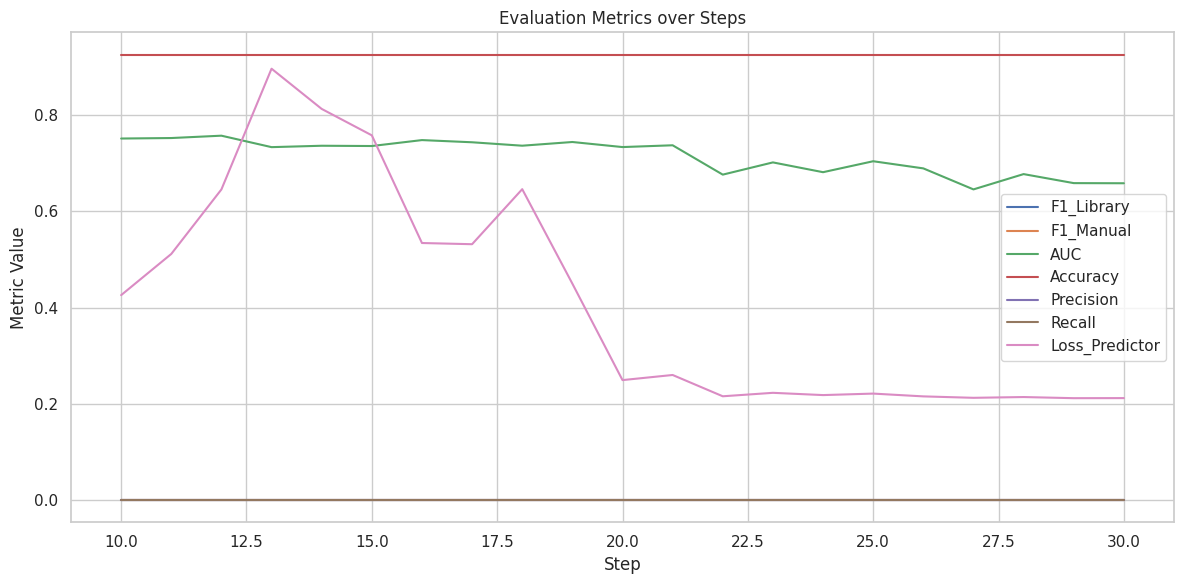

Step: 1, loss AutoEncoder: 1.081689476966858
Step: 2, loss AutoEncoder: 1.45306396484375
Step: 3, loss AutoEncoder: 0.4997442662715912
Step: 4, loss AutoEncoder: 0.24779219925403595
Step: 5, loss AutoEncoder: 0.2020261287689209
Step: 6, loss AutoEncoder: 0.14093360304832458
Step: 7, loss AutoEncoder: 0.17432869970798492
Step: 8, loss AutoEncoder: 0.14299213886260986
Step: 9, loss AutoEncoder: 0.1193123608827591
Step: 10, loss AutoEncoder: 0.09761957079172134
Step: 10, loss Predicton: 0.36927542090415955, F1-Score (Library): 8.563550105331666e-06, f1-Score: 8.563550019695798e-06, auc:0.7659331296011105, acc: 0.9257577260335287
Step: 11, loss AutoEncoder: 0.07900340855121613
Step: 11, loss Predicton: 0.5051682591438293, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7641510883382804, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.06620877236127853
Step: 12, loss Predicton: 0.7229265570640564, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7608516788778128, acc: 0.9257574081420898
St

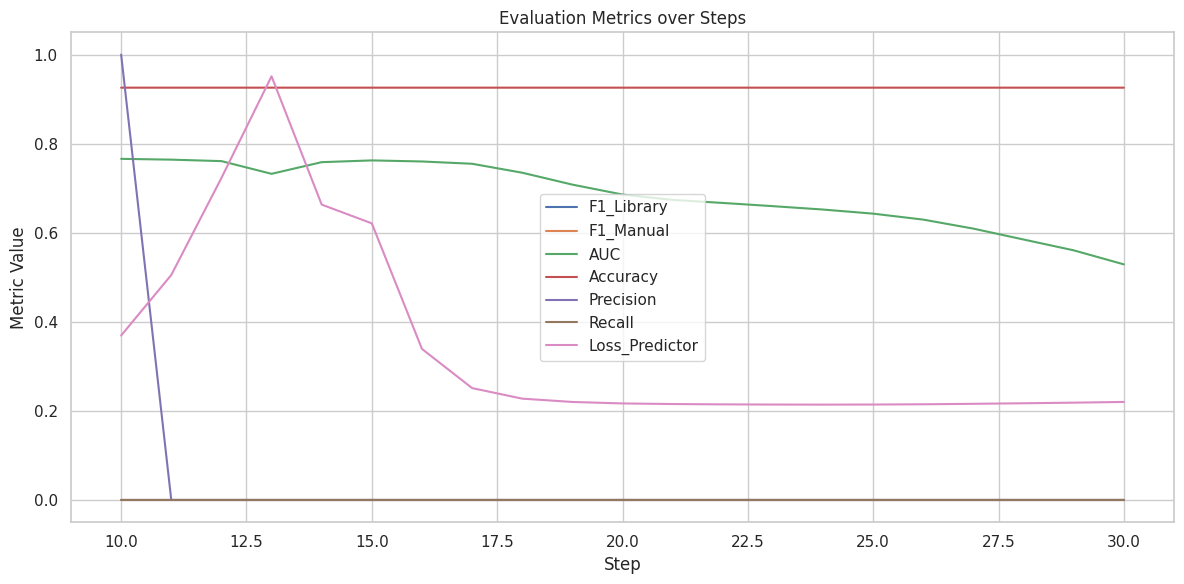

Step: 1, loss AutoEncoder: 0.9725035429000854
Step: 2, loss AutoEncoder: 1.3258519172668457
Step: 3, loss AutoEncoder: 0.42937272787094116
Step: 4, loss AutoEncoder: 0.21515662968158722
Step: 5, loss AutoEncoder: 0.10601034015417099
Step: 6, loss AutoEncoder: 0.09353404492139816
Step: 7, loss AutoEncoder: 0.1370924711227417
Step: 8, loss AutoEncoder: 0.06361860781908035
Step: 9, loss AutoEncoder: 0.04747629165649414
Step: 10, loss AutoEncoder: 0.07752295583486557
Step: 10, loss Predicton: 0.29716020822525024, F1-Score (Library): 0.11180038801087366, f1-Score: 0.11180038351204992, auc:0.6249557174428862, acc: 0.8070170084635416
Step: 11, loss AutoEncoder: 0.04670538008213043
Step: 11, loss Predicton: 0.30869409441947937, F1-Score (Library): 0.12074149648847214, f1-Score: 0.1207414921716137, auc:0.6408415559694565, acc: 0.7928873697916666
Step: 12, loss AutoEncoder: 0.028729215264320374
Step: 12, loss Predicton: 0.2974608242511749, F1-Score (Library): 0.10103487243450575, f1-Score: 0.101

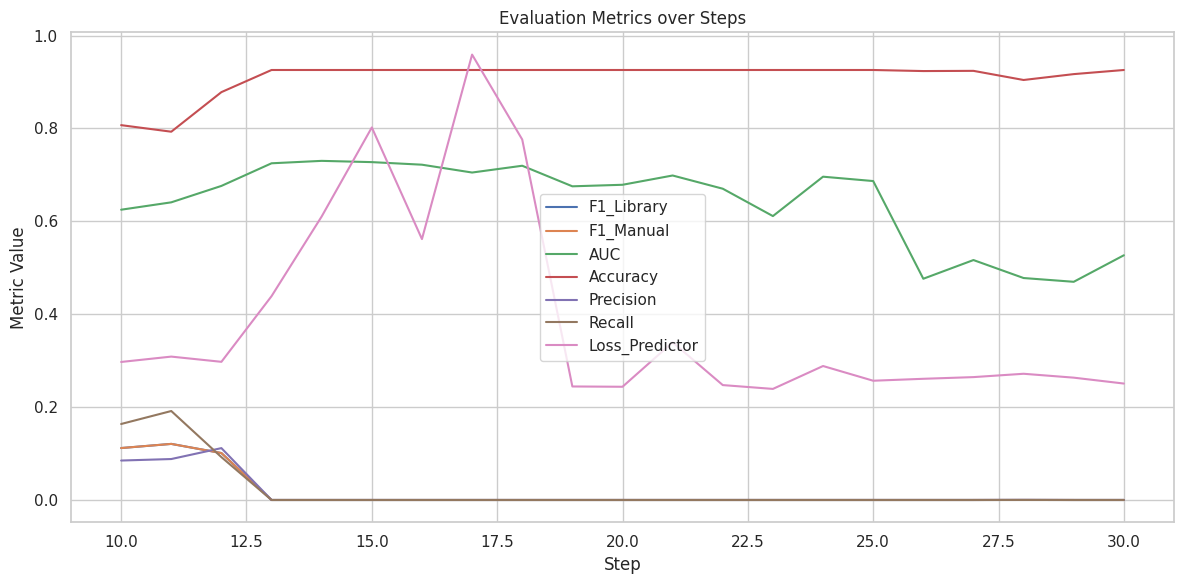

Step: 1, loss AutoEncoder: 1.105973720550537
Step: 2, loss AutoEncoder: 1.546082854270935
Step: 3, loss AutoEncoder: 0.5228698253631592
Step: 4, loss AutoEncoder: 0.2916412055492401
Step: 5, loss AutoEncoder: 0.1638101190328598
Step: 6, loss AutoEncoder: 0.1188717782497406
Step: 7, loss AutoEncoder: 0.13582603633403778
Step: 8, loss AutoEncoder: 0.23950310051441193
Step: 9, loss AutoEncoder: 0.20045937597751617
Step: 10, loss AutoEncoder: 0.1653791218996048
Step: 10, loss Predicton: 0.6577346324920654, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7707427919784351, acc: 0.9257574081420898
Step: 11, loss AutoEncoder: 0.140303835272789
Step: 11, loss Predicton: 0.7518774271011353, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7734648432211838, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.12141275405883789
Step: 12, loss Predicton: 0.8093478083610535, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7642559082975878, acc: 0.9257574081420898
Step: 13, loss AutoEncoder: 0.105256475508

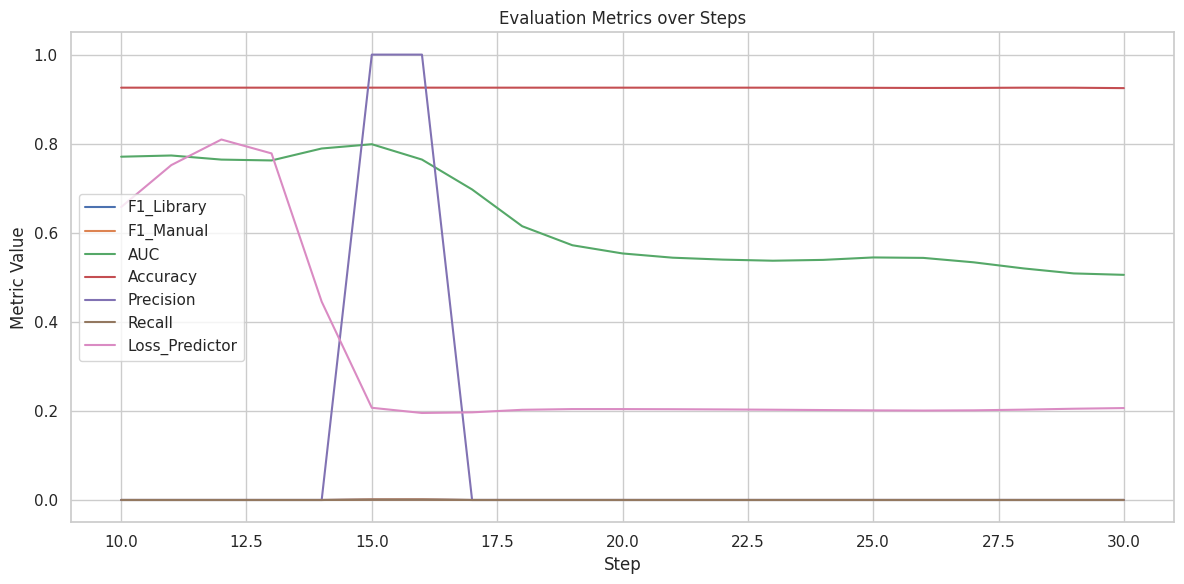

Step: 1, loss AutoEncoder: 1.159589171409607
Step: 2, loss AutoEncoder: 1.5257630348205566
Step: 3, loss AutoEncoder: 0.4897575378417969
Step: 4, loss AutoEncoder: 0.2409648895263672
Step: 5, loss AutoEncoder: 0.26383060216903687
Step: 6, loss AutoEncoder: 0.1731805056333542
Step: 7, loss AutoEncoder: 0.13937337696552277
Step: 8, loss AutoEncoder: 0.104710653424263
Step: 9, loss AutoEncoder: 0.08007808029651642
Step: 10, loss AutoEncoder: 0.06410983204841614
Step: 10, loss Predicton: 1.1308598518371582, F1-Score (Library): 0.004653327128897162, f1-Score: 0.004653326891254917, auc:0.615579279443091, acc: 0.9252033233642578
Step: 11, loss AutoEncoder: 0.05831541121006012
Step: 11, loss Predicton: 1.2196133136749268, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.5863823017887764, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.0537894032895565
Step: 12, loss Predicton: 1.1736611127853394, F1-Score (Library): 0.0013902274685066568, f1-Score: 0.0013902273880630725, auc:0.6024980528920

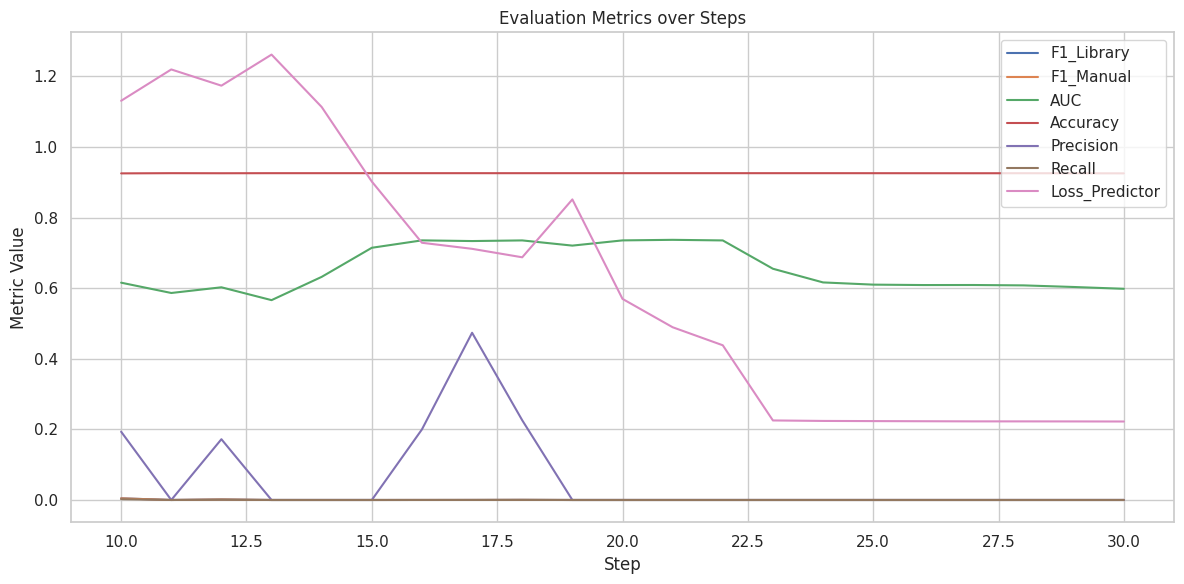

Step: 1, loss AutoEncoder: 0.8192320466041565
Step: 2, loss AutoEncoder: 1.146075963973999
Step: 3, loss AutoEncoder: 0.29054155945777893
Step: 4, loss AutoEncoder: 0.16286292672157288
Step: 5, loss AutoEncoder: 0.10074029117822647
Step: 6, loss AutoEncoder: 0.08774144947528839
Step: 7, loss AutoEncoder: 0.055107615888118744
Step: 8, loss AutoEncoder: 0.05516931787133217
Step: 9, loss AutoEncoder: 0.04144354164600372
Step: 10, loss AutoEncoder: 0.03831840306520462
Step: 10, loss Predicton: 0.9087795615196228, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6997148198735046, acc: 0.925696055094401
Step: 11, loss AutoEncoder: 0.030319178476929665
Step: 11, loss Predicton: 1.011927843093872, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6707239093451898, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.04237585514783859
Step: 12, loss Predicton: 1.088639736175537, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6530699023164976, acc: 0.9257574081420898
Step: 13, loss AutoEncoder: 0.03546

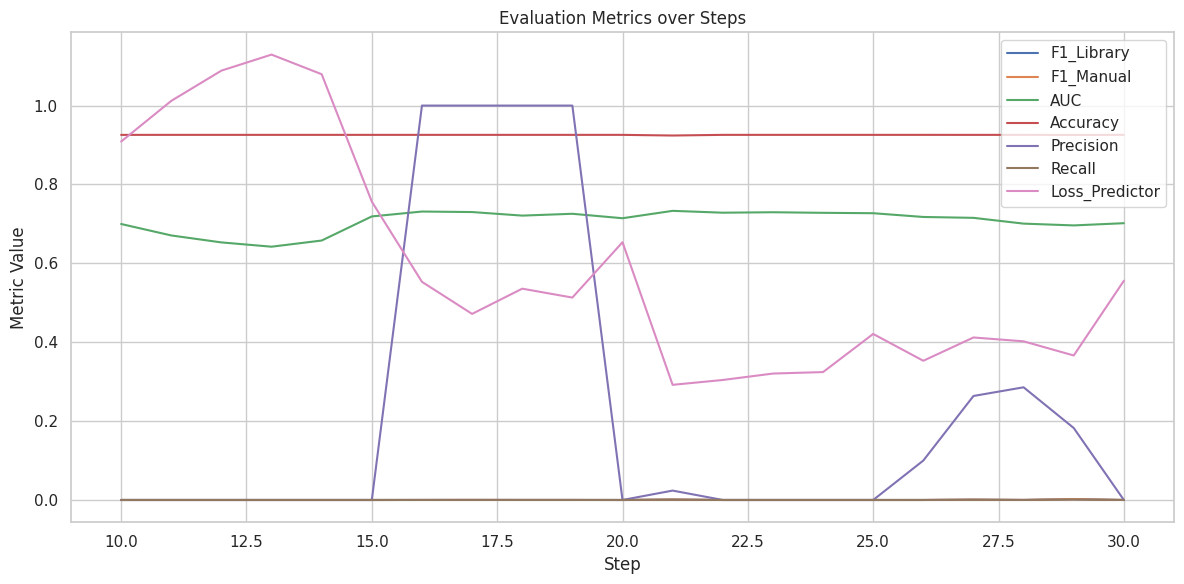

Step: 1, loss AutoEncoder: 0.9024161696434021
Step: 2, loss AutoEncoder: 1.2034873962402344
Step: 3, loss AutoEncoder: 0.3669697344303131
Step: 4, loss AutoEncoder: 0.1953936368227005
Step: 5, loss AutoEncoder: 0.11278652399778366
Step: 6, loss AutoEncoder: 0.09049549698829651
Step: 7, loss AutoEncoder: 0.08515844494104385
Step: 8, loss AutoEncoder: 0.08535454422235489
Step: 9, loss AutoEncoder: 0.0651283860206604
Step: 10, loss AutoEncoder: 0.04877748340368271
Step: 10, loss Predicton: 1.602455496788025, F1-Score (Library): 0.14819383672418338, f1-Score: 0.14819383310012657, auc:0.6627630384890373, acc: 0.7339576085408529
Step: 11, loss AutoEncoder: 0.04457787424325943
Step: 11, loss Predicton: 0.7025802135467529, F1-Score (Library): 0.06094284813898414, f1-Score: 0.06094284418507826, auc:0.6978813806909949, acc: 0.904325803120931
Step: 12, loss AutoEncoder: 0.0421491377055645
Step: 12, loss Predicton: 0.9853544235229492, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6689660318525943,

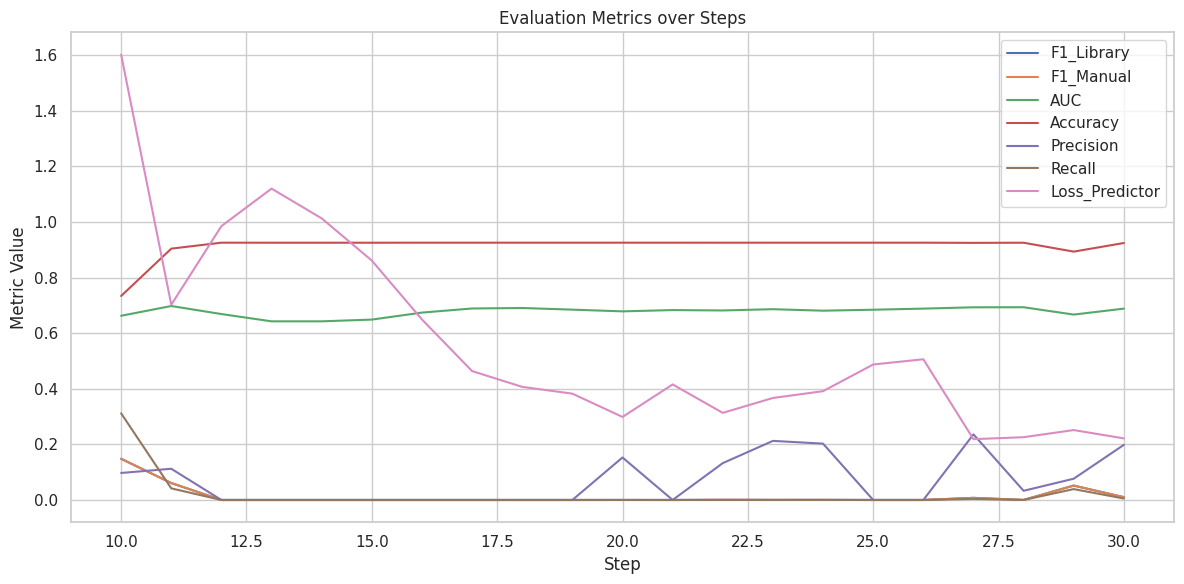

Step: 1, loss AutoEncoder: 0.9785036444664001
Step: 2, loss AutoEncoder: 1.3206812143325806
Step: 3, loss AutoEncoder: 0.3745748996734619
Step: 4, loss AutoEncoder: 0.15619038045406342
Step: 5, loss AutoEncoder: 0.13288436830043793
Step: 6, loss AutoEncoder: 0.12409657984972
Step: 7, loss AutoEncoder: 0.0920049175620079
Step: 8, loss AutoEncoder: 0.06250131875276566
Step: 9, loss AutoEncoder: 0.09414836019277573
Step: 10, loss AutoEncoder: 0.04149606451392174
Step: 10, loss Predicton: 0.6527537107467651, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7197095614844224, acc: 0.9257574081420898
Step: 11, loss AutoEncoder: 0.0464162640273571
Step: 11, loss Predicton: 0.8144102096557617, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6930528220562875, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.07104083150625229
Step: 12, loss Predicton: 0.771691083908081, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7061383059179002, acc: 0.9257574081420898
Step: 13, loss AutoEncoder: 0.0324870124

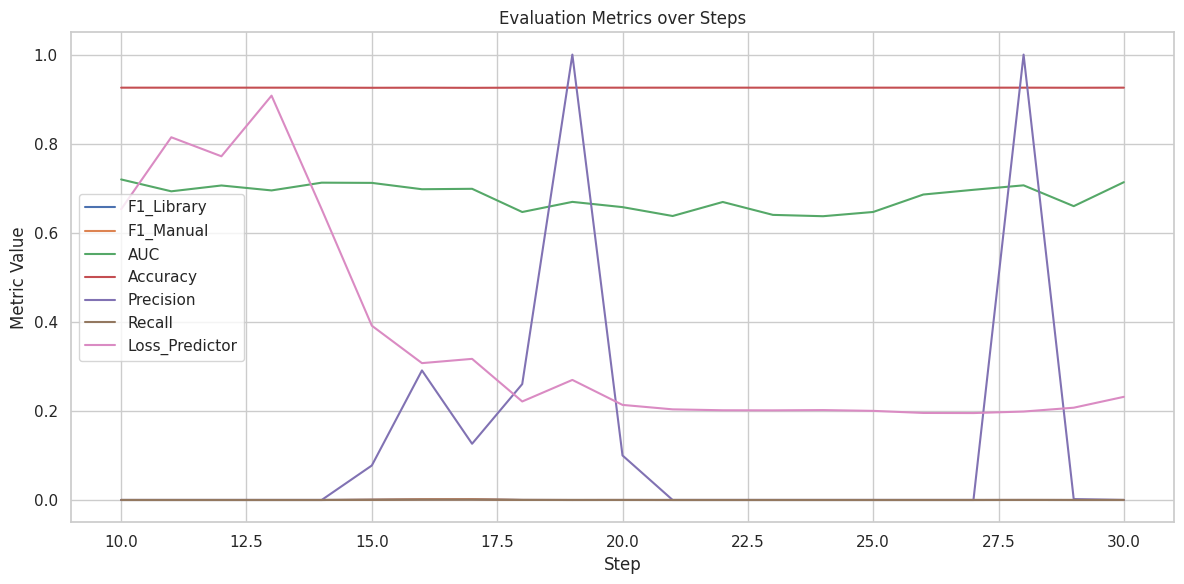

Step: 1, loss AutoEncoder: 0.9683027863502502
Step: 2, loss AutoEncoder: 1.311646819114685
Step: 3, loss AutoEncoder: 0.39648765325546265
Step: 4, loss AutoEncoder: 0.17564716935157776
Step: 5, loss AutoEncoder: 0.1500575840473175
Step: 6, loss AutoEncoder: 0.16727827489376068
Step: 7, loss AutoEncoder: 0.08813519030809402
Step: 8, loss AutoEncoder: 0.06247250363230705
Step: 9, loss AutoEncoder: 0.06958732008934021
Step: 10, loss AutoEncoder: 0.04769832268357277
Step: 10, loss Predicton: 0.9145653247833252, F1-Score (Library): 0.007123238546989739, f1-Score: 0.007123237628054268, auc:0.6847500086890694, acc: 0.9225470225016276
Step: 11, loss AutoEncoder: 0.0617063045501709
Step: 11, loss Predicton: 0.9707423448562622, F1-Score (Library): 0.00018749813567194644, f1-Score: 0.0001874980405051275, auc:0.665871991424811, acc: 0.9254147211710612
Step: 12, loss AutoEncoder: 0.042630523443222046
Step: 12, loss Predicton: 1.0543015003204346, F1-Score (Library): 7.706931100035965e-05, f1-Score: 

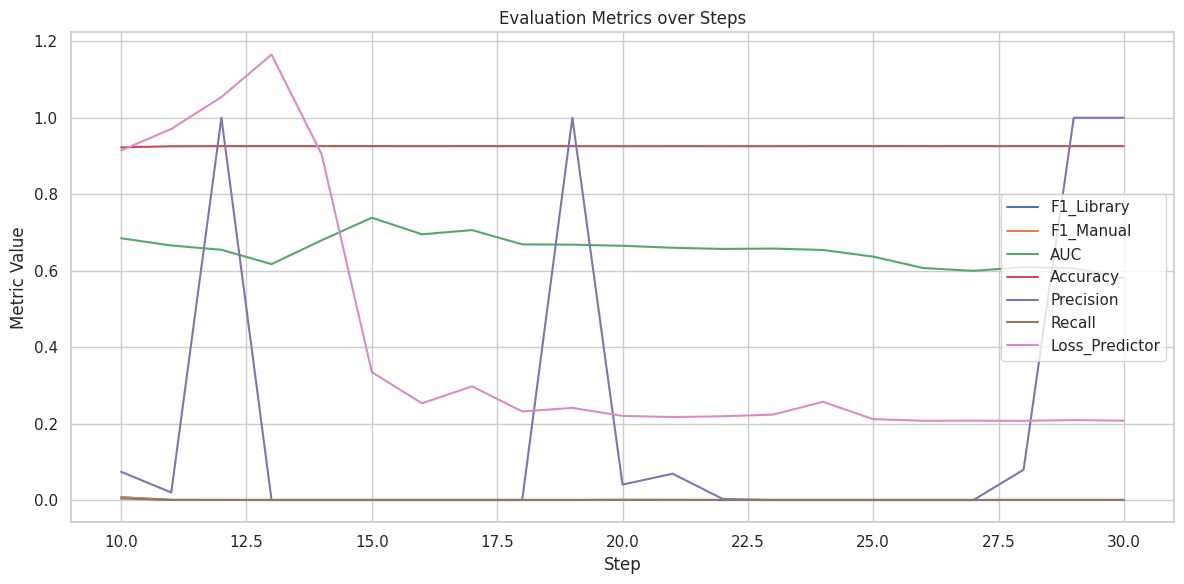

Step: 1, loss AutoEncoder: 0.9398353099822998
Step: 2, loss AutoEncoder: 1.3445038795471191
Step: 3, loss AutoEncoder: 0.41430601477622986
Step: 4, loss AutoEncoder: 0.15595613420009613
Step: 5, loss AutoEncoder: 0.11245517432689667
Step: 6, loss AutoEncoder: 0.09598064422607422
Step: 7, loss AutoEncoder: 0.0696030780673027
Step: 8, loss AutoEncoder: 0.11081121861934662
Step: 9, loss AutoEncoder: 0.1477971374988556
Step: 10, loss AutoEncoder: 0.1337364763021469
Step: 10, loss Predicton: 0.855082631111145, F1-Score (Library): 0.058247320083027666, f1-Score: 0.05824731726218922, auc:0.6755244099628623, acc: 0.9157702128092448
Step: 11, loss AutoEncoder: 0.11318574100732803
Step: 11, loss Predicton: 1.0204371213912964, F1-Score (Library): 0.0009158841706112457, f1-Score: 0.00091588416145652, auc:0.633564629895969, acc: 0.9257914225260416
Step: 12, loss AutoEncoder: 0.0963543951511383
Step: 12, loss Predicton: 0.9574631452560425, F1-Score (Library): 0.029377821870381245, f1-Score: 0.029377

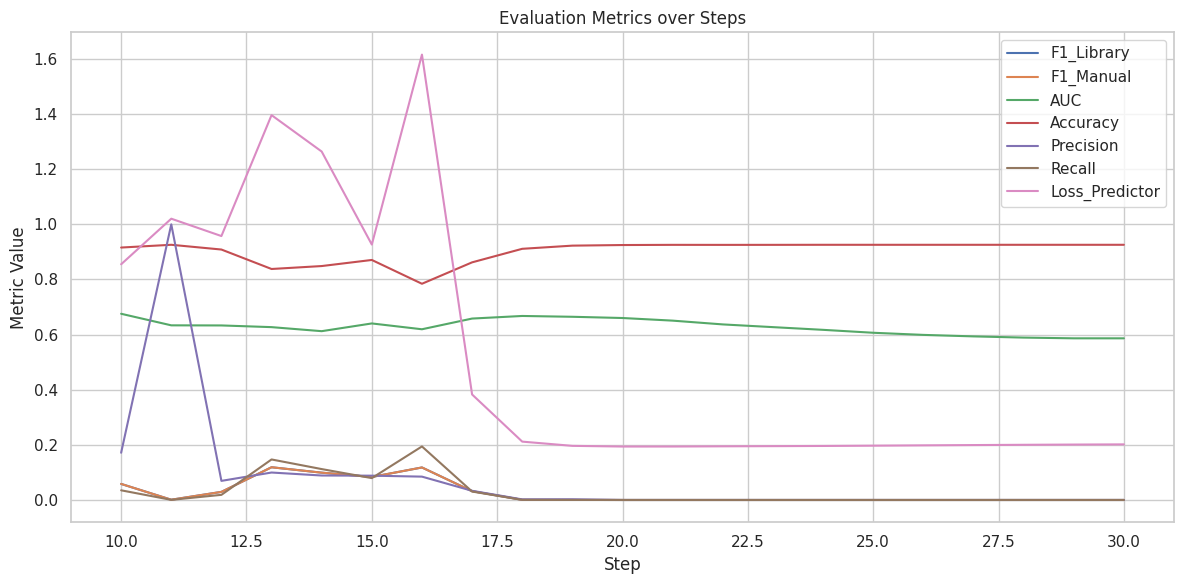

Step: 1, loss AutoEncoder: 1.0369290113449097
Step: 2, loss AutoEncoder: 1.5783681869506836
Step: 3, loss AutoEncoder: 0.4306778311729431
Step: 4, loss AutoEncoder: 0.2883107364177704
Step: 5, loss AutoEncoder: 0.26268818974494934
Step: 6, loss AutoEncoder: 0.15538157522678375
Step: 7, loss AutoEncoder: 0.13678675889968872
Step: 8, loss AutoEncoder: 0.11196983605623245
Step: 9, loss AutoEncoder: 0.08582185208797455
Step: 10, loss AutoEncoder: 0.06845469772815704
Step: 10, loss Predicton: 1.0898725986480713, F1-Score (Library): 0.026305971630192333, f1-Score: 0.026305966908446207, auc:0.7121610838590029, acc: 0.8830175399780273
Step: 11, loss AutoEncoder: 0.10583031177520752
Step: 11, loss Predicton: 1.031581997871399, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.6950911128580275, acc: 0.9237321217854818
Step: 12, loss AutoEncoder: 0.09438765048980713
Step: 12, loss Predicton: 1.1810845136642456, F1-Score (Library): 0.08657471419417934, f1-Score: 0.08657470920674244, auc:0.702032235959

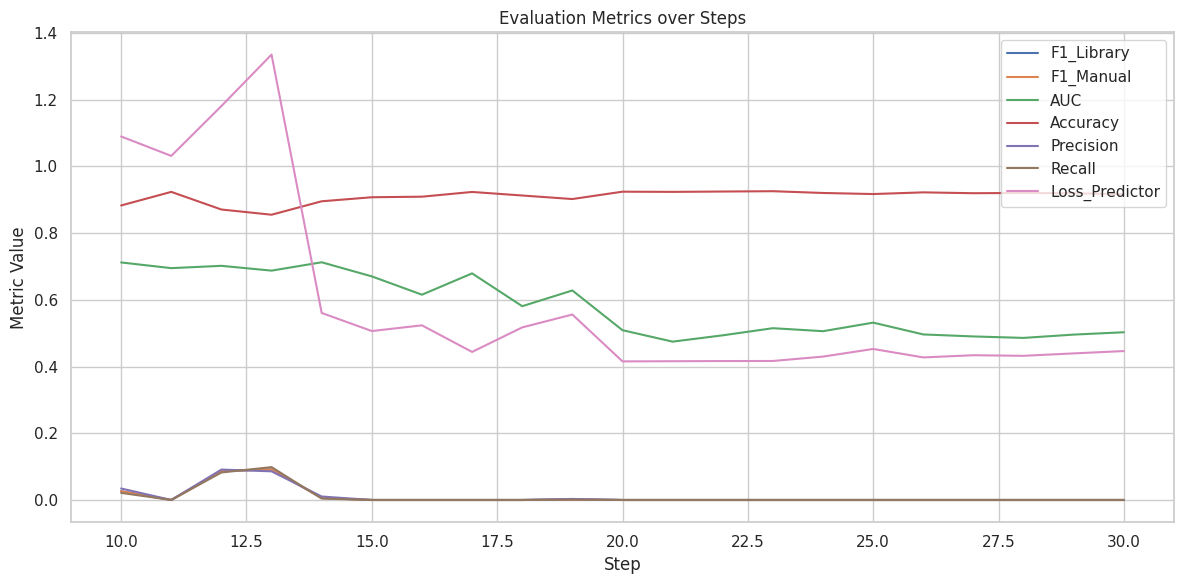

Step: 1, loss AutoEncoder: 0.9942748546600342
Step: 2, loss AutoEncoder: 1.320321798324585
Step: 3, loss AutoEncoder: 0.45700258016586304
Step: 4, loss AutoEncoder: 0.23689475655555725
Step: 5, loss AutoEncoder: 0.1067238450050354
Step: 6, loss AutoEncoder: 0.14990995824337006
Step: 7, loss AutoEncoder: 0.11520673334598541
Step: 8, loss AutoEncoder: 0.06185536831617355
Step: 9, loss AutoEncoder: 0.0747126117348671
Step: 10, loss AutoEncoder: 0.05011705309152603
Step: 10, loss Predicton: 0.3732066750526428, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7535501745963666, acc: 0.9257141749064127
Step: 11, loss AutoEncoder: 0.05237254872918129
Step: 11, loss Predicton: 0.48424968123435974, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7491975056215565, acc: 0.9257574081420898
Step: 12, loss AutoEncoder: 0.03889145329594612
Step: 12, loss Predicton: 0.6813961863517761, F1-Score (Library): 0.0, f1-Score: 0.0, auc:0.7296851083118069, acc: 0.9256728490193685
Step: 13, loss AutoEncoder: 0.03272

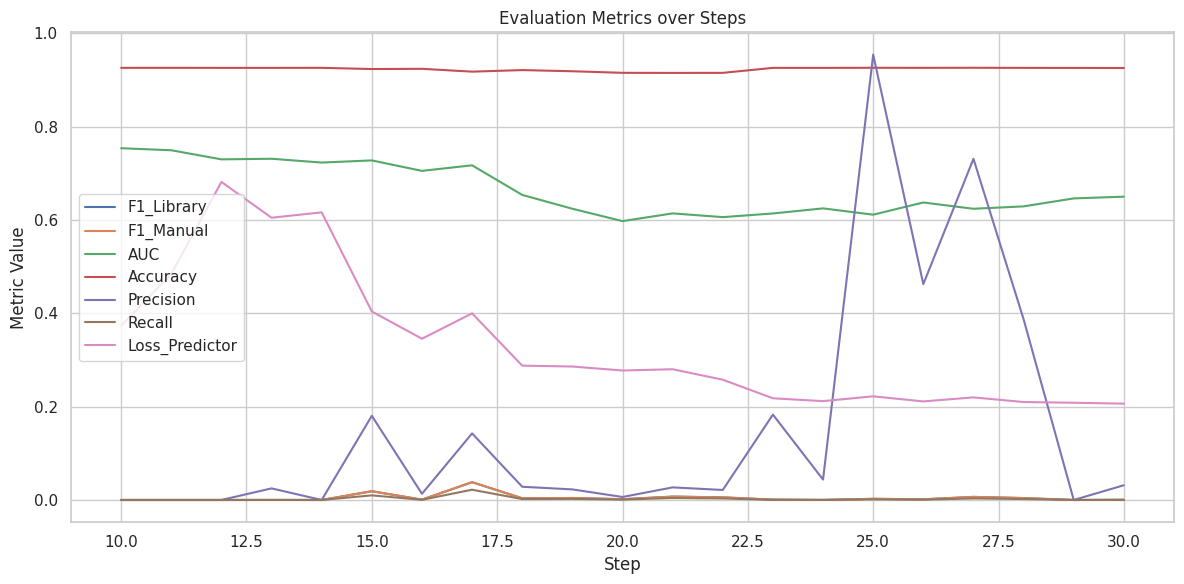

Step: 1, loss AutoEncoder: 0.977855384349823
Step: 2, loss AutoEncoder: 1.5808334350585938
Step: 3, loss AutoEncoder: 0.43154802918434143
Step: 4, loss AutoEncoder: 0.18859507143497467
Step: 5, loss AutoEncoder: 0.11913211643695831
Step: 6, loss AutoEncoder: 0.13258831202983856
Step: 7, loss AutoEncoder: 0.09916926920413971
Step: 8, loss AutoEncoder: 0.09251467138528824
Step: 9, loss AutoEncoder: 0.0658516213297844
Step: 10, loss AutoEncoder: 0.04420267418026924
Step: 10, loss Predicton: 0.9040857553482056, F1-Score (Library): 0.02934137356578052, f1-Score: 0.02934136925016832, auc:0.7181940617308729, acc: 0.8947944641113281
Step: 11, loss AutoEncoder: 0.08437882363796234
Step: 11, loss Predicton: 1.0069725513458252, F1-Score (Library): 0.023787640619944626, f1-Score: 0.023787636189115554, auc:0.7046350588139632, acc: 0.8916152318318685
Step: 12, loss AutoEncoder: 0.053114812821149826
Step: 12, loss Predicton: 1.3035893440246582, F1-Score (Library): 0.0008295026440396779, f1-Score: 0.0

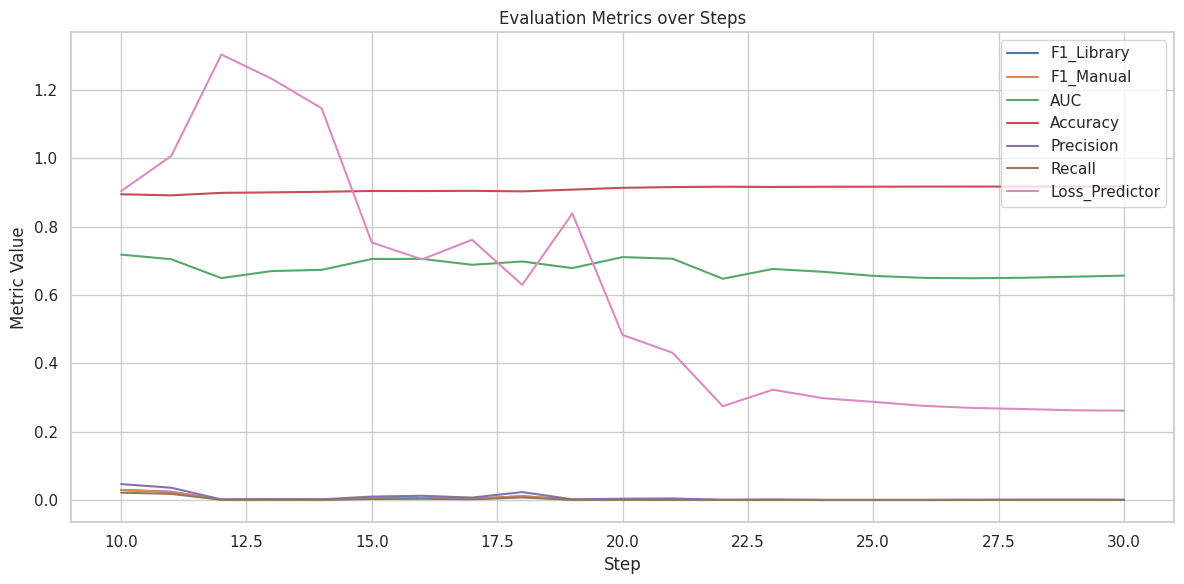

In [ ]:
for step in common_steps:
  sampler = NeuralBatchSampler(input_size=256, crop_size=128, patch_size=64, move_size=24, action_space=9).to(device)
  autoencoder = Autoencoder(K=200).to(device)
  predictor = Predictor(input_channels=10).to(device)

  predictor_path = models["predictor"][step]
  sampler_path = models["sampler"][step]

  checkpoint_pred = torch.load(predictor_path, map_location=torch.device('cuda'))
  checkpoint_samp = torch.load(sampler_path, map_location=torch.device('cuda'))
  predictor.load_state_dict(checkpoint_pred)
  sampler.load_state_dict(checkpoint_samp)

  # Define the Autoencoder loss (Mean Squared Error) and optimizer (Adam)
  autoencoder_loss = nn.MSELoss()  # MSE loss for reconstruction
  autoencoder_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)  # Adam optimizer for AE
  # Define the Predictor loss (Binary Cross Entropy) and optimizer (Adam)
  predictor_loss = CustomPredictorLoss(alpha=0.5)  # BCE loss for classification

  buffer_capacity = 10
  count = sum(1 for _, ground_truth in test_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1)
  h_l = [deque(maxlen=buffer_capacity) for _ in range(count)]
  y_l = [ground_truth for _, ground_truth in test_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1]

  alpha = 0.5
  minibatch_size = 10
  j = 0
  patches, patches_c6, centers, index = [], [], [], []
  test_loader = DataLoader(test_data, batch_size=1, shuffle=False, pin_memory=True)
  metrics_log = []
  for i, (image, ground_truth) in enumerate(test_loader):
    z = 0
    exist_flag = False
    while not exist_flag:
      if j == 30: break
      if z == 0:
        sampler.eval()
        with torch.no_grad():
          patch, channel_6, center = sampler.initial_patches(image)
          center = center[0]
          patches.append(patch.squeeze(0).to(device))
          patches_c6.append(channel_6.squeeze(0).squeeze(0).to(device))
          centers.append(center)
          index.append(i)
          patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
          del patch, channel_6
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()

          #print(f'1 {i}')
          z+=1
      elif z != 0:
        #print(f'2 {i}')
        sampler.eval()
        with torch.no_grad():
          crop, center_crop = sampler.select_crops(image, center)
          reconstructed_crop = autoencoder.forward(crop[:, :3, :, :].to(device))
          #print(crop[:, :3, :, :].size(), reconstructed_crop.size())
          crop = crop.clone().to(device)
          crop[:, 4, :, :] = torch.mean((crop[:, :3, :, :] - reconstructed_crop.detach()) ** 2, dim=1)
          #print(crop.size())
          action_probs = sampler.forward(crop)
          ######################################################################
          action = torch.argmax(action_probs, dim=1, keepdim=True)
          if action == 0:
            #print('change state')
            #print(len(patches))
            exist_flag = True
          else:
            patch, channel_6, center = sampler.move_select_patches(image=image, action=int(action[0].item()), center=center_crop)
            patches.append(patch.squeeze(0).to(device))
            patches_c6.append(channel_6.squeeze(0).to(device))
            centers.append(center)
            index.append(i)
            patch, channel_6 = patch.detach().cpu(), channel_6.detach().cpu()
            del patch, channel_6
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
          crop, reconstructed_crop, action, action_probs = crop.detach().cpu(), reconstructed_crop.detach().cpu(), action.detach().cpu(), action_probs.detach().cpu()
          del crop, reconstructed_crop, action, action_probs
          gc.collect()
          torch.cuda.empty_cache()
          torch.cuda.ipc_collect()
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):
        j += 1
        autoencoder.train()
        patches_c6 = torch.stack(patches_c6).to(device)
        patches_c6_1 = patches_c6.clone().to(device)
        patches = torch.stack(patches).to(device)
        patches_1 = patches.clone().to(device)
        autoencoder_optimizer.zero_grad() # remove gradient
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.grad_fn)
        #print(reconstructeds.size())
        loss_ae = autoencoder_loss(reconstructeds, patches)
        loss_ae.backward() # Backpropagation
        autoencoder_optimizer.step() # update weight AE

        # Move data to CPU to free GPU memory
        reconstructeds = reconstructeds.detach().cpu()
        patches = patches.detach().cpu()
        patches_c6 = patches_c6.detach().cpu()
        print(f'Step: {j}, loss AutoEncoder: {loss_ae}')

        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        del patches, patches_c6, centers, index
        patches = []
        patches_c6 = []
        #print(len(patches))
        centers = []
        index = []
        del reconstructeds, loss_ae
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        autoencoder.eval()
        with torch.no_grad():
          l, u = 0, 0
          for ind, (imag, labe) in enumerate(test_data):
            #print(image.unsqueeze(0).size())
            imag = imag.to(device)
            reconstructed = autoencoder.forward(imag.unsqueeze(0)[:, :3, :, :])
            #print(reconstructed.size())
            #error =
            #print(error.squeeze(0).size())
            if isinstance(labe, torch.Tensor) and labe.dim() != 1:
              h_l[l].append(torch.mean((imag.unsqueeze(0)[:, :3, :, :] - reconstructed) ** 2, dim=1).squeeze(0).cpu())
              l+=1
            #elif isinstance(labe, torch.Tensor) and labe.dim() == 1:
              #h_u[u].append(error.squeeze(0).cpu())
              #u+=1

            del imag, labe, reconstructed
            torch.cuda.empty_cache()
            if ind % 100 == 0:
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()

        gc.collect()
        os.system('echo 1 > /proc/sys/vm/drop_caches')
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        autoencoder.train()

        if all(len(deq) == buffer_capacity for deq in h_l):
            predictor.eval()
            with torch.no_grad():
              loss_profiles_sample = [torch.stack([t.to(device) for t in deq]) for deq in h_l]

              loss_profiles_sample = torch.stack(loss_profiles_sample).to(device)
              labels_samples = torch.stack(y_l).to(device)

              prediction_logits = predictor(loss_profiles_sample) # Forward pass through the predicton

              loss_p = predictor_loss(labels_samples.squeeze(), prediction_logits.squeeze())  # use the correct loss function

              prediction_probs = torch.sigmoid(prediction_logits)  # apply sigmoid
              prediction_binary = (prediction_probs > 0.5).float()  # threshold to get binary mask


              y_true = labels_samples.detach().cpu().numpy().flatten()
              y_pred = prediction_binary.detach().cpu().numpy().flatten()

              f1 = f1_score(y_true, y_pred)


              y_true = labels_samples.view(-1).cpu().numpy()
              y_score = prediction_binary.view(-1).detach().cpu().numpy()
              y_prob = prediction_probs.view(-1).detach().cpu().numpy()
              auc_score = roc_auc_score(y_true, y_prob)

              acc = accuracy_score(y_true, y_score)


              pred_binary = prediction_binary.int().flatten()
              true_binary = labels_samples.int().flatten()
              TP = ((pred_binary == 1) & (true_binary == 1)).sum().item()
              FP = ((pred_binary == 1) & (true_binary == 0)).sum().item()
              FN = ((pred_binary == 0) & (true_binary == 1)).sum().item()
              precision = TP / (TP + FP + 1e-8)
              recall = TP / (TP + FN + 1e-8)
              f12 = 2 * precision * recall / (precision + recall + 1e-8)
              metrics_log.append({
                  "Step": j,
                  "F1_Library": f1, "F1_Manual": f12, "AUC": auc_score,
                  "Accuracy": acc, "Precision": precision, "Recall": recall,
                  "Loss_Predictor": loss_p.item()})



              #del prediction_logits, prediction_probs, prediction_binary
              gc.collect()
              torch.cuda.empty_cache()
              torch.cuda.ipc_collect()
              print(f'Step: {j}, loss Predicton: {loss_p}, F1-Score (Library): {f1}, f1-Score: {f12}, auc:{auc_score}, acc: {acc}')

  df_metrics = pd.DataFrame(metrics_log)
  df_metrics = df_metrics.sort_values(by="Step").reset_index(drop=True)
  print(df_metrics)
  plt.figure(figsize=(12, 6))
  sns.set(style="whitegrid")
  for col in df_metrics.columns:
      if col != "Step":
          sns.lineplot(x="Step", y=col, data=df_metrics, label=col)

  plt.title("Evaluation Metrics over Steps")
  plt.xlabel("Step")
  plt.ylabel("Metric Value")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#/content/drive/MyDrive/Results/May 5, 2025/cell_output_up tot epoch 26.txt

In [ ]:
import re

# مسیر فایل
file_path = "/content/drive/MyDrive/Results/May 5, 2025/cell_output_up tot epoch 26.txt"

# دیکشنری نهایی
predictor_losses = {}

# الگوی تطبیق خط Predictor
pattern = r"Epoch: (\d+), Step: (\d+), loss Predicton: ([\d\.]+);"

with open(file_path, 'r') as file:
    for line in file:
        match = re.search(pattern, line)
        if match:
            epoch, step, loss = match.groups()
            epoch = int(epoch)
            step = int(step)
            loss = float(loss)

            key = (epoch, step)
            if key not in predictor_losses:
                predictor_losses[key] = []

            predictor_losses[key].append(loss)

In [ ]:
average_losses = {key: sum(values) / len(values) for key, values in predictor_losses.items()}

In [ ]:
sort_value = sorted(average_losses.items())

In [ ]:
x_labels = [f"E{epoch}_S{step}" for (epoch, step), _ in sort_value]
y_values = [loss for _, loss in sort_value]

In [ ]:
import matplotlib.pyplot as plt

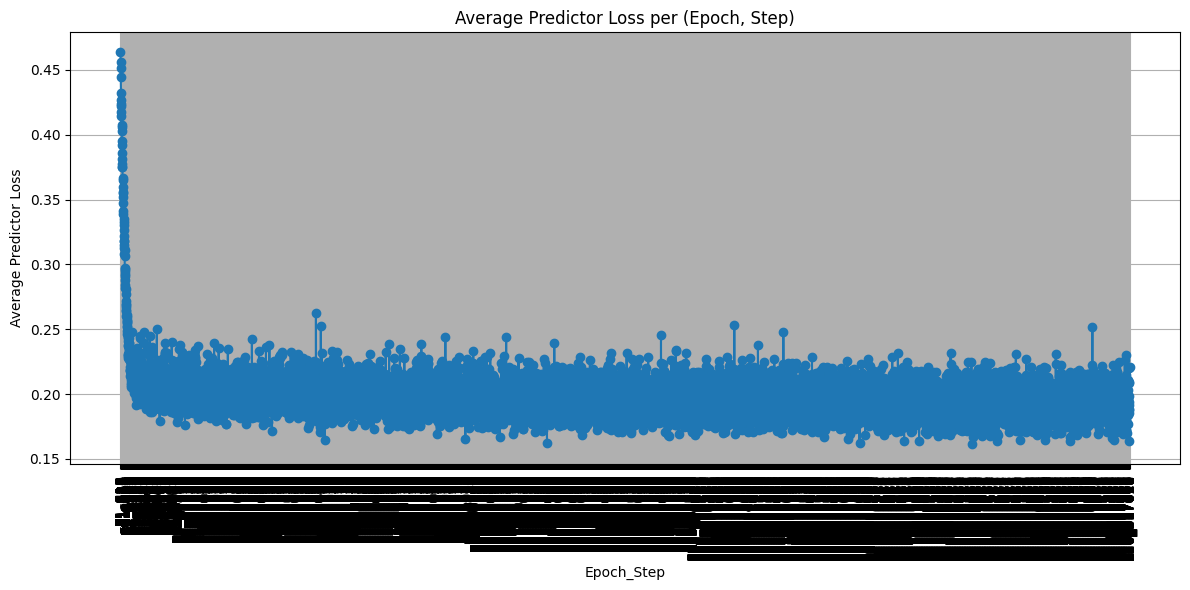

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_labels, y_values, marker='o')
plt.xticks(rotation=90)
plt.xlabel('Epoch_Step')
plt.ylabel('Average Predictor Loss')
plt.title('Average Predictor Loss per (Epoch, Step)')
plt.tight_layout()
plt.show()

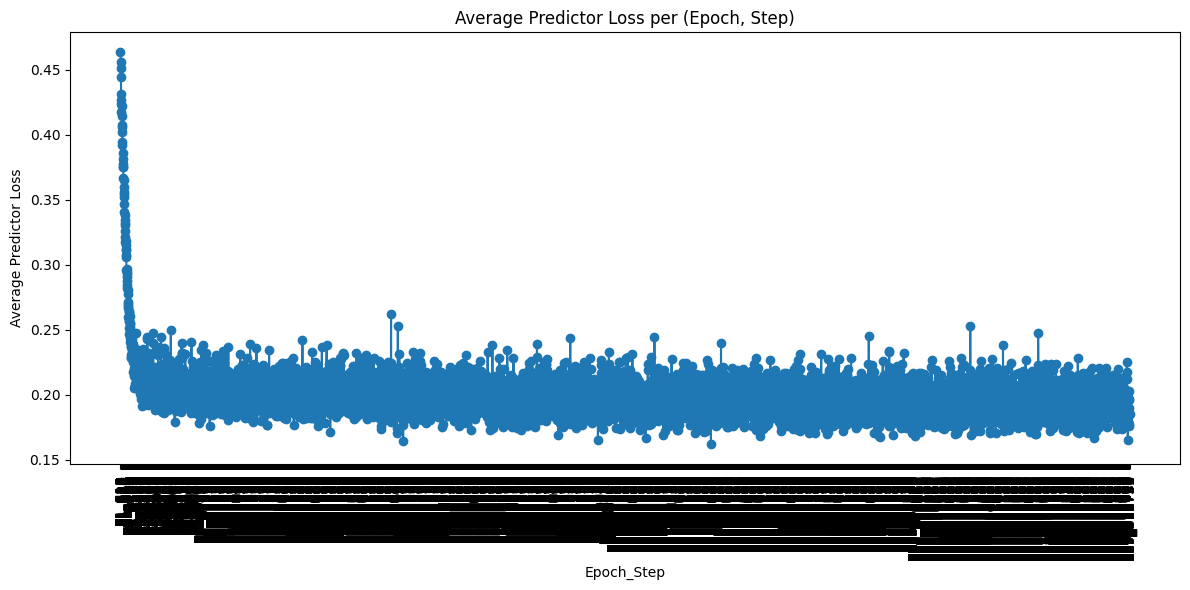

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_labels[0:7001], y_values[0:7001], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Epoch_Step')
plt.ylabel('Average Predictor Loss')
plt.title('Average Predictor Loss per (Epoch, Step)')
plt.tight_layout()
plt.show()

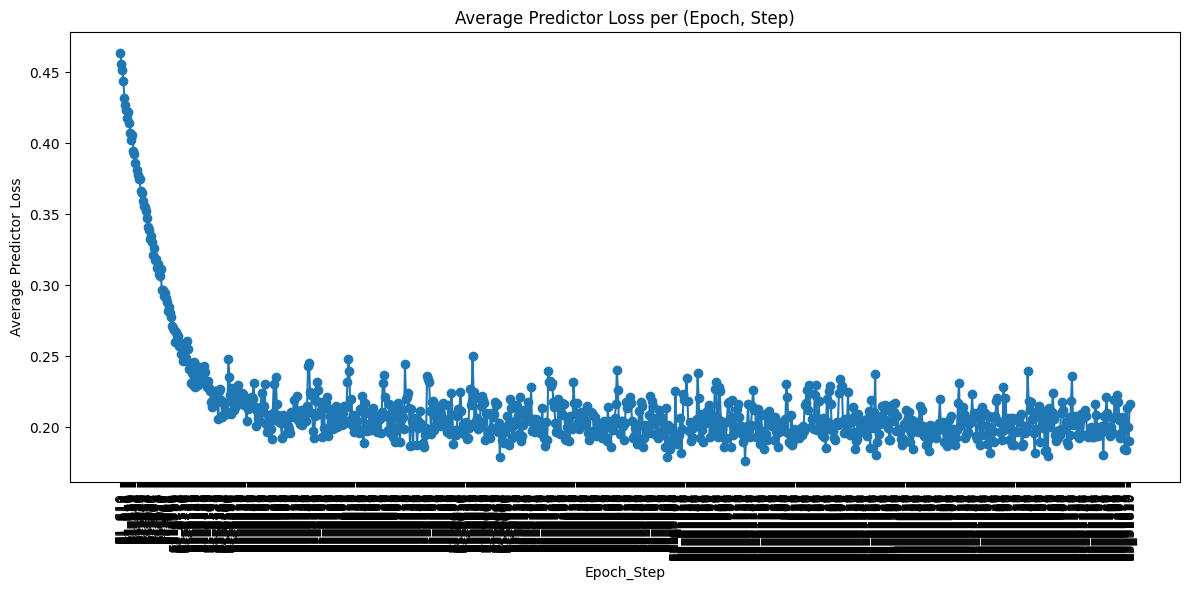

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_labels[0:1001], y_values[0:1001], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Epoch_Step')
plt.ylabel('Average Predictor Loss')
plt.title('Average Predictor Loss per (Epoch, Step)')
plt.tight_layout()
plt.show()

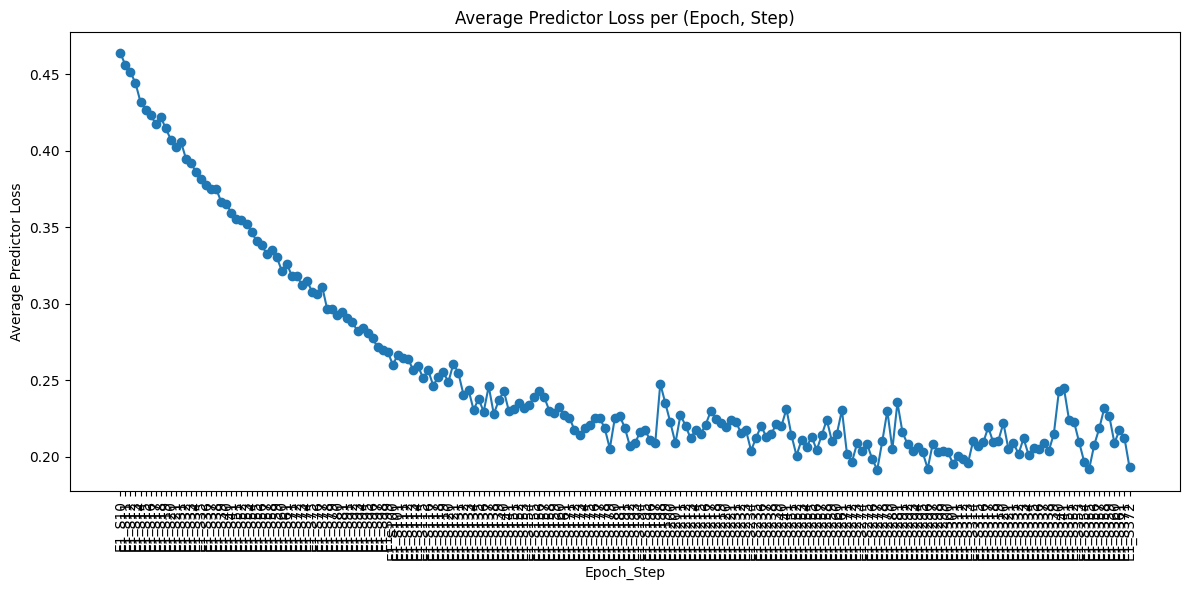

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_labels[0:201], y_values[0:201], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Epoch_Step')
plt.ylabel('Average Predictor Loss')
plt.title('Average Predictor Loss per (Epoch, Step)')
plt.tight_layout()
plt.show()

In [ ]:
import re
from collections import defaultdict

epoch_losses = defaultdict(list)

with open(file_path, 'r') as file:
    for line in file:
        match = re.search(pattern, line)
        if match:
            epoch, _, loss = match.groups()
            epoch = int(epoch)
            loss = float(loss)

            epoch_losses[epoch].append(loss)

In [ ]:
average_epoch_losses = {epoch: sum(losses) / len(losses) for epoch, losses in epoch_losses.items()}

In [ ]:
sorted_average_losses = sorted(average_epoch_losses.items())

In [ ]:
x_labels1 = [f"E{epoch}" for epoch, _ in sorted_average_losses]
y_values1 = [loss for _, loss in sorted_average_losses]

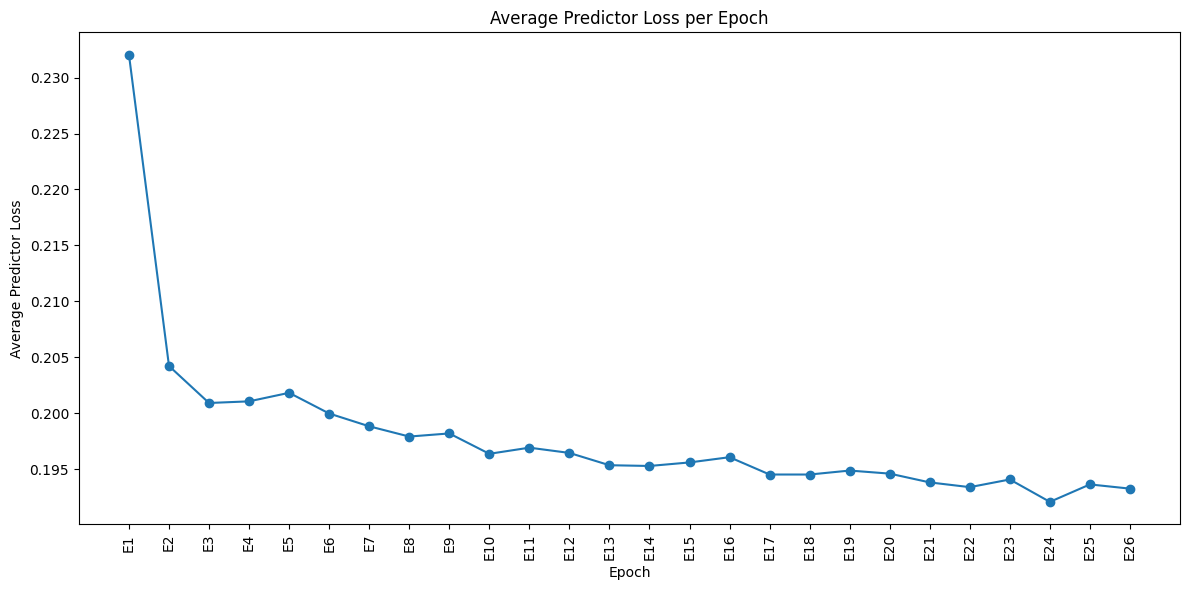

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(x_labels1, y_values1, marker='o')
plt.xticks(rotation=90)
plt.xlabel('Epoch')
plt.ylabel('Average Predictor Loss')
plt.title('Average Predictor Loss per Epoch')
plt.tight_layout()
plt.show()